<a href="https://colab.research.google.com/github/CodeClosed/Cloud-Project/blob/main/Cloud_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Kaggle API Authentication

This project uses the modern Kaggle API token authentication method.

The API token is stored securely as an environment variable and is not
hardcoded into the notebook or committed to the Git repository.

Authentication method:

KAGGLE_API_TOKEN

In [1]:
%pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.6 MB/s eta 0:00:00


In [1]:
import kaggle

print("Kaggle package imported successfully.")

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token
Kaggle package imported successfully.


# Step 2: Kaggle API Authentication

The Kaggle API package is installed successfully.

Authentication will use a Kaggle API token stored as an environment variable.

The token should never be committed to GitHub or hardcoded in the final project.

In [2]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_65fa029d955389bf8d7cc11d312802cd"

print("Kaggle API token has been configured for this notebook session.")

Kaggle API token has been configured for this notebook session.


In [3]:
import kaggle

try:
    kaggle.api.authenticate()
    print("✅ Kaggle authentication successful!")
except Exception as e:
    print(f"❌ Authentication failed: {e}")

✅ Kaggle authentication successful!


# Step 3: Dataset Discovery and Metadata Inspection

Before downloading datasets, we identify candidate datasets for the
three-model chest X-ray analysis system.

The datasets must support:

1. Lung segmentation
2. Disease classification
3. Infection or severity analysis

We inspect dataset metadata first to evaluate dataset size, structure,
licenses, and available files before downloading the full datasets.

In [5]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

search_queries = [
    "chest xray lung segmentation masks",
    "covid pneumonia normal chest xray",
    "chest xray infection segmentation severity"
]

for query in search_queries:
    print("\n" + "=" * 80)
    print(f"SEARCH QUERY: {query}")
    print("=" * 80)

    datasets = api.dataset_list(search=query)

    for dataset in datasets[:10]:
        print(f"\nDataset ID: {dataset.ref}")
        print(f"Title: {dataset.title}")

        if hasattr(dataset, "lastUpdated"):
            print(f"Last Updated: {dataset.lastUpdated}")

        if hasattr(dataset, "downloadCount"):
            print(f"Downloads: {dataset.downloadCount}")

        if hasattr(dataset, "voteCount"):
            print(f"Votes: {dataset.voteCount}")


SEARCH QUERY: chest xray lung segmentation masks

Dataset ID: farhanhaikhan/unet-lung-segmentation-dataset-siim-covid
Title: UNET Lung Segmentation Dataset SIIM COVID

Dataset ID: farhanhaikhan/unet-lung-segmentation-weights-for-chest-x-rays
Title: UNET Lung Segmentation Weights for Chest X Rays

Dataset ID: azkihimmawan/chest-xray-masks-and-defect-detection
Title: Chest X-Ray Masks and Defect Detection

Dataset ID: nikhilpandey360/chest-xray-masks-and-labels
Title: Chest Xray Masks and Labels 

Dataset ID: vbookshelf/pneumothorax-chest-xray-images-and-masks
Title: Chest X-Ray Images with Pneumothorax Masks

Dataset ID: felipemeganha/chest-xray-masks-and-labels-images
Title: Chest Xray Masks and Labels Images

Dataset ID: snehasrishti/lung-segmentation
Title: Lung segmentation

SEARCH QUERY: covid pneumonia normal chest xray

Dataset ID: amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset
Title: COVID19_Pneumonia_Normal_Chest_Xray_PA_Dataset

Dataset ID: yash612/covidnet-min

# Step 4: Candidate Dataset Inspection

Dataset search has identified candidate datasets for lung segmentation
and disease classification.

Before downloading any dataset, we inspect:

- Dataset metadata
- File structure
- Available file types
- Dataset size
- Presence of masks or labels

For the adaptive analysis model, additional searches will use targeted
terms such as infection masks, COVID lesion segmentation, and severity
grading.

In [8]:
candidate_datasets = [
    "farhanhaikhan/unet-lung-segmentation-dataset-siim-covid",
    "nikhilpandey360/chest-xray-masks-and-labels",
    "snehasrishti/lung-segmentation",
    "amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset"
]

for dataset_ref in candidate_datasets:

    print("\n" + "=" * 100)
    print(f"DATASET: {dataset_ref}")
    print("=" * 100)

    try:
        result = api.dataset_list_files(dataset_ref)

        print("\nFILES:")

        files = result.files

        for file in files[:30]:
            print(f" - {file.name}")

        if len(files) > 30:
            print(f"\n... and {len(files) - 30} more files")

    except Exception as e:
        print(f"❌ Could not inspect dataset")
        print(f"Error: {type(e).__name__}: {e}")


DATASET: farhanhaikhan/unet-lung-segmentation-dataset-siim-covid

FILES:
 - 0.png
 - 1.png
 - 2.png
 - 3.png
 - 4.png
 - 5.png
 - 6.png
 - 7.png
 - 8.png
 - meta.csv
 - segmented_data/segmented_data/test/0026720152f5.png
 - segmented_data/segmented_data/test/00fc8fc35dc1.png
 - segmented_data/segmented_data/test/01c3512eebc3.png
 - segmented_data/segmented_data/test/01f948f8e544.png
 - segmented_data/segmented_data/test/022146012034.png
 - segmented_data/segmented_data/test/02eceb0fc405.png
 - segmented_data/segmented_data/test/03a778f5a68b.png
 - segmented_data/segmented_data/test/03fa9d7e94a8.png
 - segmented_data/segmented_data/test/040d0765b661.png
 - segmented_data/segmented_data/test/0418a303883e.png

DATASET: nikhilpandey360/chest-xray-masks-and-labels

FILES:
 - Lung Segmentation/.ipynb_checkpoints/Montgomery-checkpoint.ipynb
 - Lung Segmentation/CXR_png/CHNCXR_0001_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0002_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0003_0.png
 - Lung Segm

# Step 5: Candidate Dataset File Inspection

The installed Kaggle API does not support `dataset_view()`.

Instead, we use the supported `dataset_list_files()` method to inspect
the file structure of candidate datasets before downloading them.

This allows us to determine whether each dataset contains:

- Chest X-ray images
- Lung segmentation masks
- Disease labels
- Infection masks
- Severity-related annotations

In [11]:
candidate_datasets = [
    "farhanhaikhan/unet-lung-segmentation-dataset-siim-covid",
    "nikhilpandey360/chest-xray-masks-and-labels",
    "snehasrishti/lung-segmentation",
    "amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset"
]

for dataset_ref in candidate_datasets:

    print("\n" + "=" * 100)
    print(f"DATASET: {dataset_ref}")
    print("=" * 100)

    try:
        result = api.dataset_list_files(dataset_ref)

        print("\nFILES:")

        files = result.files

        for file in files[:30]:
            print(f" - {file.name}")

        if len(files) > 30:
            print(f"\n... and {len(files) - 30} more files")

    except Exception as e:
        print(f"❌ Could not inspect dataset")
        print(f"Error: {type(e).__name__}: {e}")


DATASET: farhanhaikhan/unet-lung-segmentation-dataset-siim-covid

FILES:
 - 0.png
 - 1.png
 - 2.png
 - 3.png
 - 4.png
 - 5.png
 - 6.png
 - 7.png
 - 8.png
 - meta.csv
 - segmented_data/segmented_data/test/0026720152f5.png
 - segmented_data/segmented_data/test/00fc8fc35dc1.png
 - segmented_data/segmented_data/test/01c3512eebc3.png
 - segmented_data/segmented_data/test/01f948f8e544.png
 - segmented_data/segmented_data/test/022146012034.png
 - segmented_data/segmented_data/test/02eceb0fc405.png
 - segmented_data/segmented_data/test/03a778f5a68b.png
 - segmented_data/segmented_data/test/03fa9d7e94a8.png
 - segmented_data/segmented_data/test/040d0765b661.png
 - segmented_data/segmented_data/test/0418a303883e.png

DATASET: nikhilpandey360/chest-xray-masks-and-labels

FILES:
 - Lung Segmentation/.ipynb_checkpoints/Montgomery-checkpoint.ipynb
 - Lung Segmentation/CXR_png/CHNCXR_0001_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0002_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0003_0.png
 - Lung Segm

# Step 6: Dataset Structure Analysis

We inspect the candidate datasets at the directory level before
downloading them.

The goal is to verify:

- Image directories
- Mask directories
- Class directories
- File extensions
- Number of files

This allows us to confirm that the datasets are suitable for their
respective models before committing storage and preprocessing resources.

In [9]:
from collections import Counter

candidate_datasets = [
    "nikhilpandey360/chest-xray-masks-and-labels",
    "amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset"
]

for dataset_ref in candidate_datasets:

    print("\n" + "=" * 100)
    print(f"DATASET: {dataset_ref}")
    print("=" * 100)

    try:
        result = api.dataset_list_files(dataset_ref)
        files = result.files

        # Extract top-level and second-level folder structure
        folder_counter = Counter()

        for file in files:
            parts = file.name.split("/")

            if len(parts) >= 2:
                folder = "/".join(parts[:2])
            else:
                folder = parts[0]

            folder_counter[folder] += 1

        print("\nDIRECTORY STRUCTURE:")

        for folder, count in folder_counter.most_common():
            print(f"{folder}: {count} files")

        # File extension distribution
        extension_counter = Counter()

        for file in files:
            filename = file.name.lower()

            if "." in filename:
                extension = "." + filename.split(".")[-1]
            else:
                extension = "[no extension]"

            extension_counter[extension] += 1

        print("\nFILE TYPES:")

        for extension, count in extension_counter.most_common():
            print(f"{extension}: {count}")

        print(f"\nTOTAL FILES: {len(files)}")

    except Exception as e:
        print(f"❌ Could not inspect dataset")
        print(f"Error: {type(e).__name__}: {e}")


DATASET: nikhilpandey360/chest-xray-masks-and-labels

DIRECTORY STRUCTURE:
Lung Segmentation/CXR_png: 19 files
Lung Segmentation/.ipynb_checkpoints: 1 files

FILE TYPES:
.png: 19
.ipynb: 1

TOTAL FILES: 20

DATASET: amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset

DIRECTORY STRUCTURE:
covid/001.jpeg: 1 files
covid/002.jpeg: 1 files
covid/003.jpeg: 1 files
covid/004.jpeg: 1 files
covid/005.jpeg: 1 files
covid/006.jpeg: 1 files
covid/007.jpg: 1 files
covid/008.jpg: 1 files
covid/009.jpg: 1 files
covid/010.jpeg: 1 files
covid/011.jpeg: 1 files
covid/012.jpeg: 1 files
covid/013.jpeg: 1 files
covid/014.jpeg: 1 files
covid/015.jpeg: 1 files
covid/016.jpeg: 1 files
covid/017.jpeg: 1 files
covid/018.jpeg: 1 files
covid/019.jpeg: 1 files
covid/01E392EE-69F9-4E33-BFCE-E5C968654078-768x572.jpeg: 1 files

FILE TYPES:
.jpeg: 17
.jpg: 3

TOTAL FILES: 20


# Step 7: Kaggle Dataset File Pagination

The previous inspection returned exactly 20 files for multiple datasets,
indicating that the Kaggle API is returning only a default page of results.

Before analyzing dataset structure, we inspect the supported parameters of
`dataset_list_files()` and the returned response object.

This ensures that the complete dataset file listing is retrieved rather
than only the first page.

In [12]:
import inspect

print("dataset_list_files() signature:")
print(inspect.signature(api.dataset_list_files))

print("\n" + "=" * 80)

result = api.dataset_list_files(
    "nikhilpandey360/chest-xray-masks-and-labels"
)

print("Response object type:")
print(type(result))

print("\nAvailable response attributes:")
print([
    attr for attr in dir(result)
    if not attr.startswith("_")
])

dataset_list_files() signature:
(dataset, page_token=None, page_size=20)

Response object type:
<class 'kagglesdk.datasets.types.dataset_api_service.ApiListDatasetFilesResponse'>

Available response attributes:
['body_fields', 'dataset_files', 'endpoint', 'endpoint_path', 'errorMessage', 'error_message', 'files', 'from_dict', 'from_json', 'method', 'nextPageToken', 'next_page_token', 'prepare_from', 'to_dict', 'to_field_map', 'to_json']


# Step 8: Complete Dataset File Retrieval

The Kaggle API returns dataset files in pages.

To inspect an entire dataset, we use pagination with:

- `page_size`
- `next_page_token`

The loop continues until no additional page token is available.

This ensures that dataset analysis is based on the complete file structure
rather than only the first 20 files.

In [13]:
def get_all_dataset_files(api, dataset_ref, page_size=1000):
    all_files = []
    page_token = None

    while True:
        response = api.dataset_list_files(
            dataset=dataset_ref,
            page_token=page_token,
            page_size=page_size
        )

        all_files.extend(response.files)

        page_token = response.next_page_token

        if not page_token:
            break

    return all_files


# Test with the lung segmentation dataset
dataset_ref = "nikhilpandey360/chest-xray-masks-and-labels"

all_files = get_all_dataset_files(api, dataset_ref)

print(f"Dataset: {dataset_ref}")
print(f"Total files retrieved: {len(all_files)}")

print("\nFirst 20 files:")
for file in all_files[:20]:
    print(f" - {file.name}")

print("\nLast 20 files:")
for file in all_files[-20:]:
    print(f" - {file.name}")

Dataset: nikhilpandey360/chest-xray-masks-and-labels
Total files retrieved: 4806

First 20 files:
 - Lung Segmentation/.ipynb_checkpoints/Montgomery-checkpoint.ipynb
 - Lung Segmentation/CXR_png/CHNCXR_0001_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0002_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0003_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0004_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0005_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0006_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0007_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0008_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0009_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0010_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0011_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0012_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0013_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0014_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0015_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0016_0.png
 - Lung Segmentation/CXR_png/CHNCXR_0017_0.png
 - Lung Segmentation/CXR_png/CHNCXR

# Step 9: Lung Segmentation Dataset Structure Analysis

The complete file listing has been successfully retrieved using Kaggle API
pagination.

This step analyzes the full dataset structure to identify:

- Original chest X-ray images
- Lung mask directories
- Train, validation, and test splits
- Possible image-to-mask naming conventions

The goal is to verify whether the dataset can provide correctly paired
chest X-ray images and lung masks for Model 1.

In [14]:
from collections import Counter

folder_counts = Counter()

for file in all_files:
    parts = file.name.split("/")

    # Group files by their first 3 directory levels
    if len(parts) >= 3:
        folder = "/".join(parts[:3])
    elif len(parts) == 2:
        folder = "/".join(parts[:2])
    else:
        folder = parts[0]

    folder_counts[folder] += 1


print("=" * 100)
print("COMPLETE DIRECTORY STRUCTURE")
print("=" * 100)

for folder, count in sorted(folder_counts.items()):
    print(f"{folder:<70} {count:>6} files")


print("\n" + "=" * 100)
print("FILES CONTAINING MASK-RELATED KEYWORDS")
print("=" * 100)

mask_keywords = ["mask", "left", "right", "label"]

matching_files = [
    file.name
    for file in all_files
    if any(keyword in file.name.lower() for keyword in mask_keywords)
]

for filename in matching_files[:100]:
    print(filename)

print(f"\nTotal files matching mask-related keywords: {len(matching_files)}")

COMPLETE DIRECTORY STRUCTURE
Lung Segmentation/.ipynb_checkpoints/Montgomery-checkpoint.ipynb            1 files
Lung Segmentation/CXR_png/CHNCXR_0001_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0002_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0003_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0004_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0005_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0006_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0007_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0008_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0009_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0010_0.png                                 1 files
Lung Segmentation/CXR_png/CHNCXR_0011_0.png    

# Step 10: Image and Mask Pair Verification

The lung segmentation dataset contains multiple image directories and
preprocessed splits.

Before training Model 1, we verify the exact relationship between chest
X-ray images and their corresponding ground-truth lung masks.

This step examines filename patterns and searches for matching image IDs
across the dataset.

In [15]:
import re
from collections import defaultdict

# Group files by their base image ID
file_groups = defaultdict(list)

for file in all_files:
    filename = file.name.split("/")[-1]

    # Extract IDs such as CHNCXR_0001
    match = re.search(r"CHNCXR_\d+", filename)

    if match:
        image_id = match.group()
        file_groups[image_id].append(file.name)


print("=" * 100)
print("SAMPLE IMAGE ID GROUPINGS")
print("=" * 100)

shown = 0

for image_id, paths in sorted(file_groups.items()):
    if len(paths) > 1:
        print(f"\nIMAGE ID: {image_id}")

        for path in paths:
            print(f" - {path}")

        shown += 1

    if shown >= 10:
        break


print("\n" + "=" * 100)
print("PAIRING SUMMARY")
print("=" * 100)

group_sizes = Counter(len(paths) for paths in file_groups.values())

for size, count in sorted(group_sizes.items()):
    print(f"{count} image IDs appear in {size} file(s)")

SAMPLE IMAGE ID GROUPINGS

IMAGE ID: CHNCXR_0001
 - Lung Segmentation/CXR_png/CHNCXR_0001_0.png
 - Lung Segmentation/ClinicalReadings/CHNCXR_0001_0.txt
 - Lung Segmentation/masks/CHNCXR_0001_0_mask.png
 - data/Lung Segmentation/CXR_png/CHNCXR_0001_0.png
 - data/Lung Segmentation/ClinicalReadings/CHNCXR_0001_0.txt
 - data/Lung Segmentation/masks/CHNCXR_0001_0_mask.png

IMAGE ID: CHNCXR_0002
 - Lung Segmentation/CXR_png/CHNCXR_0002_0.png
 - Lung Segmentation/ClinicalReadings/CHNCXR_0002_0.txt
 - Lung Segmentation/masks/CHNCXR_0002_0_mask.png
 - data/Lung Segmentation/CXR_png/CHNCXR_0002_0.png
 - data/Lung Segmentation/ClinicalReadings/CHNCXR_0002_0.txt
 - data/Lung Segmentation/masks/CHNCXR_0002_0_mask.png

IMAGE ID: CHNCXR_0003
 - Lung Segmentation/CXR_png/CHNCXR_0003_0.png
 - Lung Segmentation/ClinicalReadings/CHNCXR_0003_0.txt
 - Lung Segmentation/masks/CHNCXR_0003_0_mask.png
 - data/Lung Segmentation/CXR_png/CHNCXR_0003_0.png
 - data/Lung Segmentation/ClinicalReadings/CHNCXR_0003_0.t

# Step 11: Lung Segmentation Dataset Integrity Check

Before downloading the lung segmentation dataset, we verify the integrity
of the canonical image and mask directories.

The dataset must satisfy:

- Each chest X-ray has exactly one corresponding lung mask
- Image and mask filenames follow a consistent naming convention
- No duplicate dataset copies are included in the training set
- Missing image-mask pairs are identified

Only the canonical directories will be used:

Lung Segmentation/CXR_png/
Lung Segmentation/masks/

In [16]:
from pathlib import PurePosixPath

IMAGE_PREFIX = "Lung Segmentation/CXR_png/"
MASK_PREFIX = "Lung Segmentation/masks/"

image_files = [
    file.name
    for file in all_files
    if file.name.startswith(IMAGE_PREFIX)
    and file.name.lower().endswith(".png")
]

mask_files = [
    file.name
    for file in all_files
    if file.name.startswith(MASK_PREFIX)
    and file.name.lower().endswith("_mask.png")
]

# Create filename sets
image_names = {
    PurePosixPath(path).name
    for path in image_files
}

mask_names = {
    PurePosixPath(path).name
    for path in mask_files
}

# Expected mask for every image
expected_mask_names = {
    image_name.replace(".png", "_mask.png")
    for image_name in image_names
}

missing_masks = sorted(
    expected_mask_names - mask_names
)

# Find masks that do not correspond to an image
expected_images_from_masks = {
    mask_name.replace("_mask.png", ".png")
    for mask_name in mask_names
}

orphan_masks = sorted(
    expected_images_from_masks - image_names
)

matched_pairs = len(image_names) - len(missing_masks)

print("=" * 80)
print("LUNG SEGMENTATION DATASET INTEGRITY REPORT")
print("=" * 80)

print(f"\nOriginal chest X-rays: {len(image_names)}")
print(f"Lung masks:            {len(mask_names)}")
print(f"Matched image-mask pairs: {matched_pairs}")

print(f"\nMissing masks: {len(missing_masks)}")
print(f"Orphan masks:  {len(orphan_masks)}")

if missing_masks:
    print("\nSample missing masks:")
    for filename in missing_masks[:10]:
        print(f" - {filename}")

if orphan_masks:
    print("\nSample orphan masks:")
    for filename in orphan_masks[:10]:
        print(f" - {filename}")

print("\n" + "=" * 80)

if not missing_masks and not orphan_masks:
    print("✅ Dataset integrity check passed.")
    print("All canonical chest X-rays have matching lung masks.")
else:
    print("⚠️ Dataset contains unmatched files.")

LUNG SEGMENTATION DATASET INTEGRITY REPORT

Original chest X-rays: 800
Lung masks:            566
Matched image-mask pairs: 566

Missing masks: 234
Orphan masks:  0

Sample missing masks:
 - CHNCXR_0025_0_mask.png
 - CHNCXR_0036_0_mask.png
 - CHNCXR_0037_0_mask.png
 - CHNCXR_0038_0_mask.png
 - CHNCXR_0039_0_mask.png
 - CHNCXR_0040_0_mask.png
 - CHNCXR_0065_0_mask.png
 - CHNCXR_0181_0_mask.png
 - CHNCXR_0182_0_mask.png
 - CHNCXR_0183_0_mask.png

⚠️ Dataset contains unmatched files.


# Step 12: Verified Lung Segmentation Pairs

The dataset contains 800 chest X-rays, but only 566 have corresponding
ground-truth lung masks.

For supervised lung segmentation training, only verified image-mask pairs
will be used.

Images without ground-truth masks are excluded from Model 1 training.

This creates a clean dataset of 566 paired samples.

In [17]:
from pathlib import PurePosixPath

valid_pairs = []

for image_path in image_files:
    image_name = PurePosixPath(image_path).name
    expected_mask_name = image_name.replace(".png", "_mask.png")

    if expected_mask_name in mask_names:
        mask_path = f"{MASK_PREFIX}{expected_mask_name}"

        valid_pairs.append({
            "image": image_path,
            "mask": mask_path
        })

print("=" * 80)
print("VERIFIED LUNG SEGMENTATION PAIRS")
print("=" * 80)

print(f"\nTotal valid image-mask pairs: {len(valid_pairs)}")

print("\nFirst 10 pairs:\n")

for pair in valid_pairs[:10]:
    print(f"Image: {pair['image']}")
    print(f"Mask:  {pair['mask']}")
    print("-" * 60)

# Final safety check
assert len(valid_pairs) == 566, "Unexpected number of valid pairs found."

print("\n✅ All verified pairs are ready for download.")

VERIFIED LUNG SEGMENTATION PAIRS

Total valid image-mask pairs: 566

First 10 pairs:

Image: Lung Segmentation/CXR_png/CHNCXR_0001_0.png
Mask:  Lung Segmentation/masks/CHNCXR_0001_0_mask.png
------------------------------------------------------------
Image: Lung Segmentation/CXR_png/CHNCXR_0002_0.png
Mask:  Lung Segmentation/masks/CHNCXR_0002_0_mask.png
------------------------------------------------------------
Image: Lung Segmentation/CXR_png/CHNCXR_0003_0.png
Mask:  Lung Segmentation/masks/CHNCXR_0003_0_mask.png
------------------------------------------------------------
Image: Lung Segmentation/CXR_png/CHNCXR_0004_0.png
Mask:  Lung Segmentation/masks/CHNCXR_0004_0_mask.png
------------------------------------------------------------
Image: Lung Segmentation/CXR_png/CHNCXR_0005_0.png
Mask:  Lung Segmentation/masks/CHNCXR_0005_0_mask.png
------------------------------------------------------------
Image: Lung Segmentation/CXR_png/CHNCXR_0006_0.png
Mask:  Lung Segmentation/masks/CH

# Step 13: Download Verified Lung Segmentation Data

Only the canonical lung segmentation data required for Model 1 will be used:

- Chest X-ray images
- Corresponding ground-truth lung masks

The dataset contains 566 verified image-mask pairs.

Duplicate copies, notebooks, clinical readings, and unmatched images will
not be included in the Model 1 training dataset.

In [18]:
from pathlib import Path

PROJECT_ROOT = Path("/content/chest_xray_project")

SEGMENTATION_DIR = PROJECT_ROOT / "data" / "segmentation"

IMAGES_DIR = SEGMENTATION_DIR / "images"
MASKS_DIR = SEGMENTATION_DIR / "masks"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MASKS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory created:")
print(PROJECT_ROOT)

Project directory created:
/content/chest_xray_project


In [19]:
SOURCE_DATASET = "nikhilpandey360/chest-xray-masks-and-labels"

RAW_DOWNLOAD_DIR = PROJECT_ROOT / "raw_downloads" / "lung_segmentation"

RAW_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

api.dataset_download_files(
    SOURCE_DATASET,
    path=str(RAW_DOWNLOAD_DIR),
    unzip=True
)

print("✅ Dataset downloaded successfully.")
print(f"Location: {RAW_DOWNLOAD_DIR}")

Dataset URL: https://www.kaggle.com/datasets/nikhilpandey360/chest-xray-masks-and-labels
✅ Dataset downloaded successfully.
Location: /content/chest_xray_project/raw_downloads/lung_segmentation


# Step 14: Create the Clean Lung Segmentation Dataset

The raw Kaggle dataset contains duplicate files, clinical readings,
unmatched chest X-rays, and other files not required for training.

A clean dataset is created using only the 566 verified image-mask pairs.

Final structure:

data/
└── segmentation/
    ├── images/
    │   ├── CHNCXR_0001_0.png
    │   └── ...
    │
    └── masks/
        ├── CHNCXR_0001_0_mask.png
        └── ...

In [20]:
import shutil
from pathlib import Path

# Raw dataset location
RAW_SOURCE_DIR = (
    RAW_DOWNLOAD_DIR
    / "Lung Segmentation"
)

RAW_IMAGES_DIR = RAW_SOURCE_DIR / "CXR_png"
RAW_MASKS_DIR = RAW_SOURCE_DIR / "masks"

# Counters
copied_pairs = 0
missing_files = []

for pair in valid_pairs:

    image_name = Path(pair["image"]).name
    mask_name = Path(pair["mask"]).name

    source_image = RAW_IMAGES_DIR / image_name
    source_mask = RAW_MASKS_DIR / mask_name

    destination_image = IMAGES_DIR / image_name
    destination_mask = MASKS_DIR / mask_name

    # Verify that both files exist locally
    if source_image.exists() and source_mask.exists():

        shutil.copy2(source_image, destination_image)
        shutil.copy2(source_mask, destination_mask)

        copied_pairs += 1

    else:
        missing_files.append({
            "image": str(source_image),
            "mask": str(source_mask)
        })


print("=" * 80)
print("CLEAN DATASET EXTRACTION REPORT")
print("=" * 80)

print(f"\nVerified pairs expected: {len(valid_pairs)}")
print(f"Pairs successfully copied: {copied_pairs}")
print(f"Pairs with missing local files: {len(missing_files)}")

print(f"\nImages directory: {IMAGES_DIR}")
print(f"Masks directory:  {MASKS_DIR}")

assert copied_pairs == len(valid_pairs), (
    "Not all verified pairs were copied successfully."
)

print("\n✅ Clean lung segmentation dataset created successfully.")

CLEAN DATASET EXTRACTION REPORT

Verified pairs expected: 566
Pairs successfully copied: 566
Pairs with missing local files: 0

Images directory: /content/chest_xray_project/data/segmentation/images
Masks directory:  /content/chest_xray_project/data/segmentation/masks

✅ Clean lung segmentation dataset created successfully.


# Step 15: Local Image and Mask Validation

Before creating train, validation, and test splits, the cleaned lung
segmentation dataset is validated locally.

The validation checks:

- All image files can be opened
- All mask files can be opened
- Image dimensions
- Mask dimensions
- Consistency between image and mask sizes
- Unique pixel values in the lung masks

This ensures that the dataset is technically valid before preprocessing
and model training.

In [21]:
from PIL import Image
import numpy as np
from collections import Counter

image_paths = sorted(IMAGES_DIR.glob("*.png"))
mask_paths = sorted(MASKS_DIR.glob("*.png"))

image_sizes = Counter()
mask_sizes = Counter()

failed_images = []
failed_masks = []
size_mismatches = []

mask_pixel_values = set()

for image_path in image_paths:
    try:
        with Image.open(image_path) as image:
            image_sizes[image.size] += 1
    except Exception as e:
        failed_images.append((image_path.name, str(e)))

for mask_path in mask_paths:
    try:
        with Image.open(mask_path) as mask:
            mask_sizes[mask.size] += 1

            mask_array = np.array(mask)
            mask_pixel_values.update(
                np.unique(mask_array).tolist()
            )

    except Exception as e:
        failed_masks.append((mask_path.name, str(e)))

# Check image-mask size consistency
for image_path in image_paths:

    mask_name = image_path.name.replace(".png", "_mask.png")
    mask_path = MASKS_DIR / mask_name

    if mask_path.exists():

        with Image.open(image_path) as image, \
             Image.open(mask_path) as mask:

            if image.size != mask.size:
                size_mismatches.append(
                    (image_path.name, image.size, mask.size)
                )

print("=" * 80)
print("LOCAL DATASET VALIDATION REPORT")
print("=" * 80)

print(f"\nTotal images: {len(image_paths)}")
print(f"Total masks:  {len(mask_paths)}")

print(f"\nFailed images: {len(failed_images)}")
print(f"Failed masks:  {len(failed_masks)}")

print(f"\nImage-mask size mismatches: {len(size_mismatches)}")

print("\nIMAGE DIMENSIONS:")
for size, count in image_sizes.most_common():
    print(f"  {size}: {count} files")

print("\nMASK DIMENSIONS:")
for size, count in mask_sizes.most_common():
    print(f"  {size}: {count} files")

print("\nUNIQUE MASK PIXEL VALUES:")
print(sorted(mask_pixel_values))

print("\n" + "=" * 80)

if (
    len(failed_images) == 0
    and len(failed_masks) == 0
    and len(size_mismatches) == 0
):
    print("✅ Local dataset validation passed.")
else:
    print("⚠️ Validation found issues that must be resolved.")

LOCAL DATASET VALIDATION REPORT

Total images: 566
Total masks:  566

Failed images: 0
Failed masks:  0

Image-mask size mismatches: 0

IMAGE DIMENSIONS:
  (3000, 2939): 14 files
  (3000, 2945): 12 files
  (3000, 2947): 10 files
  (3000, 2949): 10 files
  (3000, 2951): 9 files
  (3000, 2937): 9 files
  (3000, 2943): 9 files
  (3000, 2941): 8 files
  (3000, 2933): 6 files
  (3000, 2931): 6 files
  (3000, 2935): 4 files
  (3000, 2953): 4 files
  (3000, 2927): 3 files
  (3000, 2955): 3 files
  (3000, 2967): 3 files
  (2991, 2993): 3 files
  (2991, 2992): 3 files
  (2997, 2943): 3 files
  (3000, 2919): 2 files
  (3000, 2959): 2 files
  (2996, 2941): 2 files
  (2997, 2933): 2 files
  (2991, 2995): 2 files
  (2992, 2994): 2 files
  (3000, 2925): 2 files
  (2996, 2989): 2 files
  (3000, 2965): 2 files
  (2995, 2986): 2 files
  (3001, 2988): 2 files
  (3001, 2989): 2 files
  (2987, 2945): 1 files
  (2775, 2948): 1 files
  (2306, 2320): 1 files
  (2516, 2942): 1 files
  (3000, 2921): 1 files
  

# Step 16: Lung Mask Analysis

Before splitting and preprocessing the segmentation dataset, we analyze
the ground-truth lung masks.

This step determines:

- Whether masks are binary
- The foreground and background pixel values
- Lung coverage distribution
- Potential empty or invalid masks

The analysis helps define the correct preprocessing pipeline and
segmentation loss functions.

In [22]:
import numpy as np
from PIL import Image
import pandas as pd

mask_statistics = []

for mask_path in mask_paths:

    with Image.open(mask_path) as mask:
        mask_array = np.array(mask)

    # Convert any non-zero pixel to foreground
    binary_mask = mask_array > 0

    foreground_pixels = np.sum(binary_mask)
    total_pixels = binary_mask.size

    foreground_ratio = foreground_pixels / total_pixels

    mask_statistics.append({
        "mask_name": mask_path.name,
        "height": binary_mask.shape[0],
        "width": binary_mask.shape[1],
        "foreground_pixels": foreground_pixels,
        "foreground_ratio": foreground_ratio
    })

mask_df = pd.DataFrame(mask_statistics)

print("=" * 80)
print("LUNG MASK ANALYSIS REPORT")
print("=" * 80)

print(f"\nTotal masks analyzed: {len(mask_df)}")

print("\nForeground coverage statistics:")
print(mask_df["foreground_ratio"].describe())

empty_masks = (mask_df["foreground_pixels"] == 0).sum()

print(f"\nEmpty masks: {empty_masks}")

print(
    f"Minimum lung coverage: "
    f"{mask_df['foreground_ratio'].min():.4f}"
)

print(
    f"Maximum lung coverage: "
    f"{mask_df['foreground_ratio'].max():.4f}"
)

print(
    f"Average lung coverage: "
    f"{mask_df['foreground_ratio'].mean():.4f}"
)

assert empty_masks == 0, "Empty masks detected."

print("\n✅ Mask analysis completed successfully.")

LUNG MASK ANALYSIS REPORT

Total masks analyzed: 566

Foreground coverage statistics:
count    566.000000
mean       0.252650
std        0.057597
min        0.083505
25%        0.211100
50%        0.248333
75%        0.291953
max        0.432649
Name: foreground_ratio, dtype: float64

Empty masks: 0
Minimum lung coverage: 0.0835
Maximum lung coverage: 0.4326
Average lung coverage: 0.2526

✅ Mask analysis completed successfully.


# Step 17: Train, Validation, and Test Split

The verified lung segmentation dataset contains 566 image-mask pairs.

The dataset is divided into three independent subsets:

- Training set: 70%
- Validation set: 15%
- Test set: 15%

A fixed random seed is used to ensure that the dataset split is
reproducible across notebook executions.

The same image and its corresponding lung mask are always assigned to
the same subset.

In [23]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Create a DataFrame containing verified image-mask pairs
segmentation_df = pd.DataFrame([
    {
        "image_name": Path(pair["image"]).name,
        "mask_name": Path(pair["mask"]).name
    }
    for pair in valid_pairs
])

# First split:
# 70% train
# 30% temporary (validation + test)

train_df, temp_df = train_test_split(
    segmentation_df,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Split the remaining 30% equally into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("=" * 80)
print("LUNG SEGMENTATION DATASET SPLIT")
print("=" * 80)

print(f"\nTotal samples:      {len(segmentation_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")

print("\nPercentage distribution:")
print(f"Train: {len(train_df) / len(segmentation_df) * 100:.2f}%")
print(f"Validation: {len(val_df) / len(segmentation_df) * 100:.2f}%")
print(f"Test: {len(test_df) / len(segmentation_df) * 100:.2f}%")

# Safety checks
assert len(train_df) + len(val_df) + len(test_df) == len(segmentation_df)

assert set(train_df["image_name"]).isdisjoint(val_df["image_name"])
assert set(train_df["image_name"]).isdisjoint(test_df["image_name"])
assert set(val_df["image_name"]).isdisjoint(test_df["image_name"])

print("\n✅ Dataset split completed successfully.")
print("✅ No image appears in more than one subset.")

LUNG SEGMENTATION DATASET SPLIT

Total samples:      566
Training samples:   396
Validation samples: 85
Test samples:       85

Percentage distribution:
Train: 69.96%
Validation: 15.02%
Test: 15.02%

✅ Dataset split completed successfully.
✅ No image appears in more than one subset.


# Step 18: Visual Inspection of Image-Mask Pairs

Before training the lung segmentation model, representative samples are
visually inspected.

For each sample, we compare:

1. Original chest X-ray
2. Ground-truth lung mask
3. Mask overlaid on the chest X-ray

This verifies that the masks are correctly aligned with the lung regions
and confirms that the image-mask pairing process is valid.

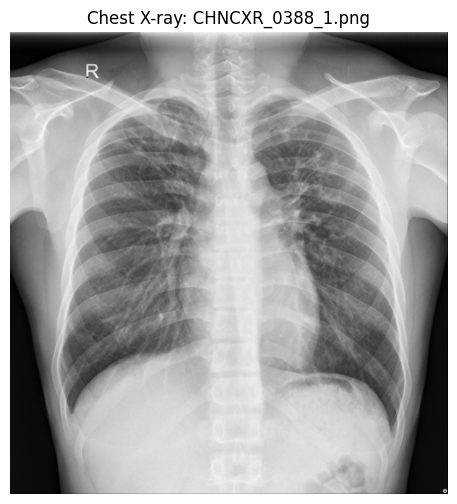

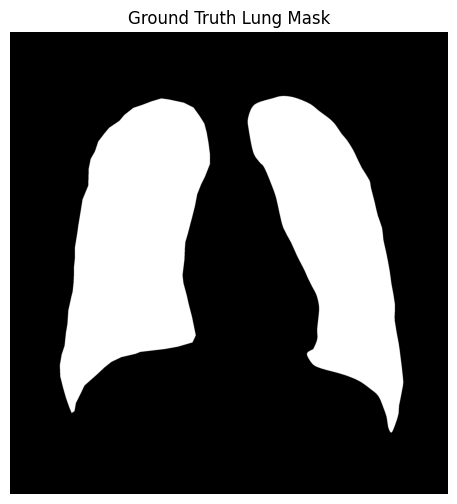

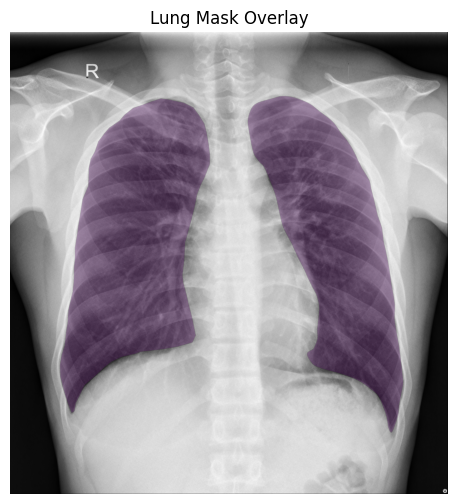

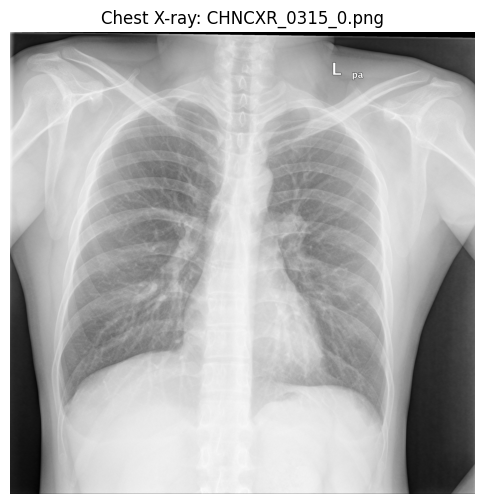

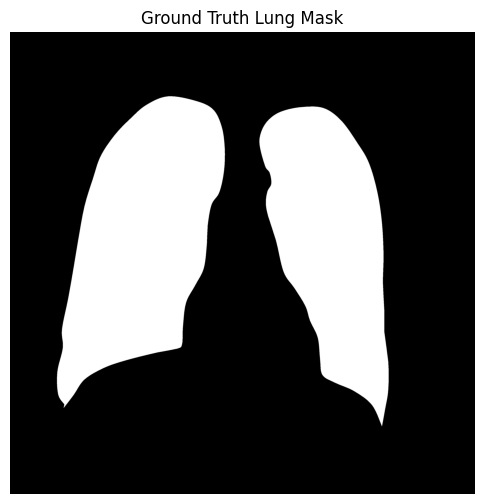

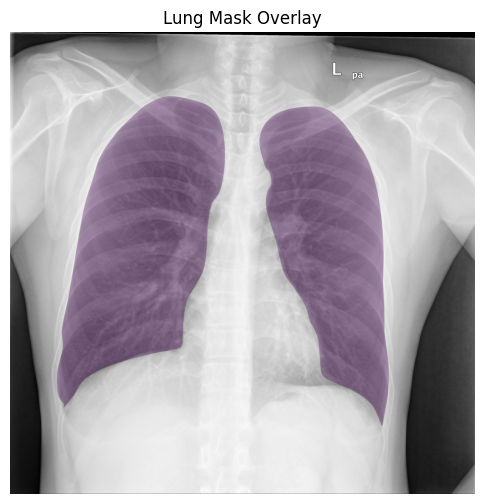

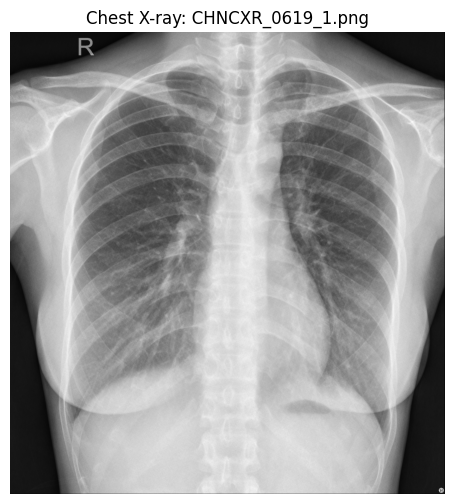

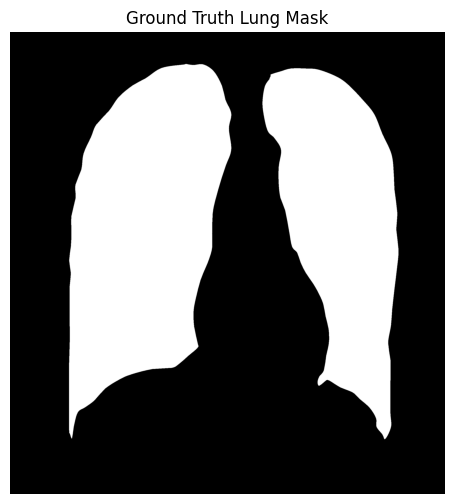

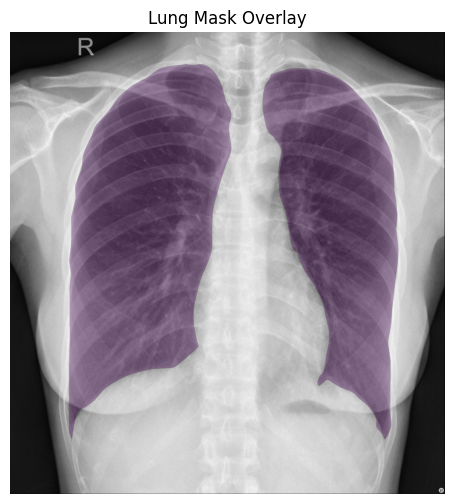

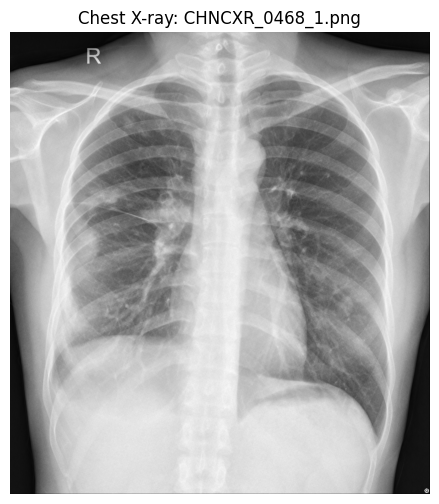

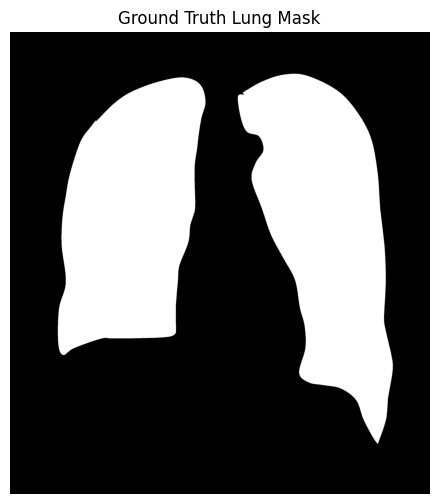

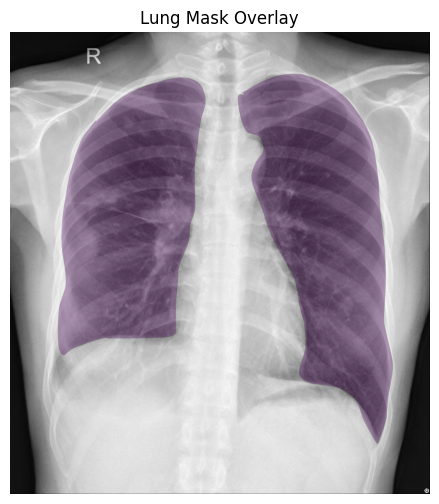

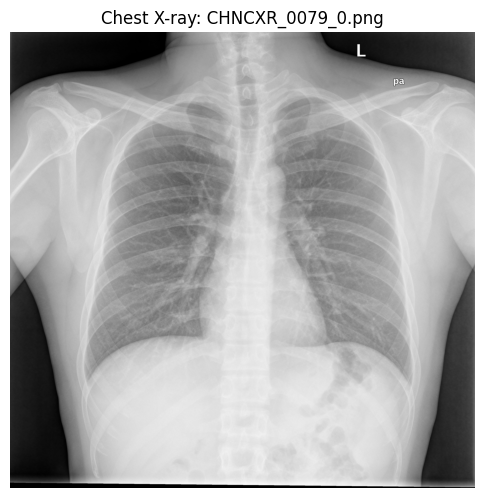

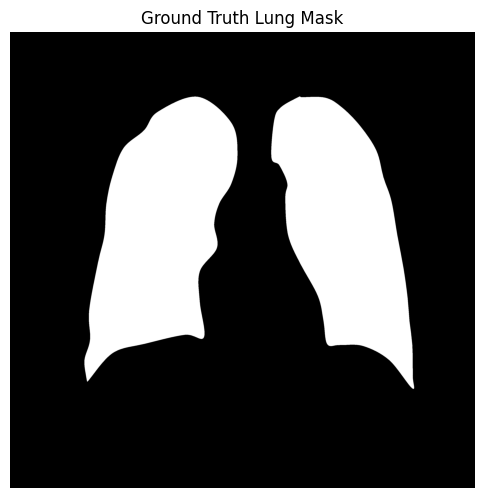

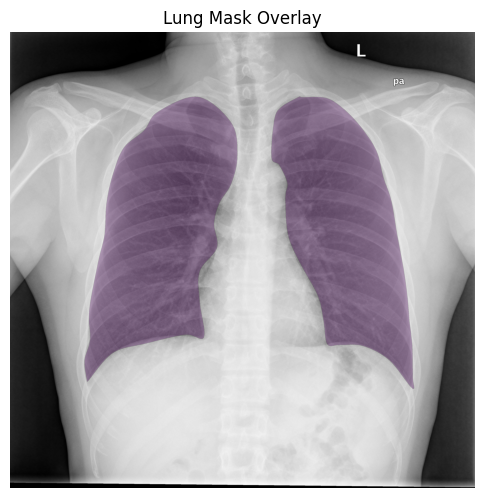

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Select reproducible random samples from the training set
samples_to_visualize = train_df.sample(
    n=5,
    random_state=42
).reset_index(drop=True)

for _, row in samples_to_visualize.iterrows():

    image_path = IMAGES_DIR / row["image_name"]
    mask_path = MASKS_DIR / row["mask_name"]

    # Load image and mask
    image = np.array(Image.open(image_path).convert("L"))
    mask = np.array(Image.open(mask_path).convert("L"))

    # Convert mask to binary
    binary_mask = mask > 0

    # Create overlay
    overlay = np.ma.masked_where(~binary_mask, binary_mask)

    # Display each sample separately
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray")
    plt.title(f"Chest X-ray: {row['image_name']}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(binary_mask, cmap="gray")
    plt.title("Ground Truth Lung Mask")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray")
    plt.imshow(overlay, alpha=0.35)
    plt.title("Lung Mask Overlay")
    plt.axis("off")
    plt.show()

# Step 19: Lung Segmentation Preprocessing Pipeline

The lung segmentation model requires a consistent input format.

Each chest X-ray will be:

1. Loaded as a grayscale image
2. Resized to 256 × 256 pixels
3. Converted to floating-point format
4. Normalized to the range [0, 1]

Each corresponding lung mask will be:

1. Loaded as a grayscale mask
2. Resized to 256 × 256 using nearest-neighbor interpolation
3. Converted into a binary mask

The final model input will have the shape:

(256, 256, 1)

The target mask will have the shape:

(256, 256, 1)

In [25]:
import tensorflow as tf

IMAGE_SIZE = 256

def load_image_mask(image_name, mask_name):

    image_path = tf.strings.join([
        str(IMAGES_DIR) + "/",
        image_name
    ])

    mask_path = tf.strings.join([
        str(MASKS_DIR) + "/",
        mask_name
    ])

    # Load chest X-ray
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        [IMAGE_SIZE, IMAGE_SIZE],
        method="bilinear"
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0


    # Load lung mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(
        mask,
        channels=1
    )

    mask = tf.image.resize(
        mask,
        [IMAGE_SIZE, IMAGE_SIZE],
        method="nearest"
    )

    # Convert mask to binary
    mask = tf.cast(
        mask > 0,
        tf.float32
    )

    return image, mask


# Test preprocessing using one training sample

sample = train_df.iloc[0]

processed_image, processed_mask = load_image_mask(
    sample["image_name"],
    sample["mask_name"]
)

print("=" * 80)
print("PREPROCESSING VALIDATION")
print("=" * 80)

print(f"\nProcessed image shape: {processed_image.shape}")
print(f"Processed mask shape:  {processed_mask.shape}")

print(
    f"\nImage value range: "
    f"{tf.reduce_min(processed_image).numpy():.4f} "
    f"to "
    f"{tf.reduce_max(processed_image).numpy():.4f}"
)

print(
    f"Mask unique values: "
    f"{tf.unique(tf.reshape(processed_mask, [-1]))[0].numpy()}"
)

# Safety checks
assert processed_image.shape == (256, 256, 1)
assert processed_mask.shape == (256, 256, 1)

print("\n✅ Preprocessing pipeline validation passed.")

PREPROCESSING VALIDATION

Processed image shape: (256, 256, 1)
Processed mask shape:  (256, 256, 1)

Image value range: 0.0000 to 1.0000
Mask unique values: [0. 1.]

✅ Preprocessing pipeline validation passed.


# Step 20: TensorFlow Data Pipeline

The train, validation, and test splits are converted into TensorFlow
`tf.data.Dataset` objects.

The pipeline performs:

1. Image and mask file loading
2. Preprocessing and resizing
3. Binary mask conversion
4. Training data shuffling
5. Batch creation
6. Dataset prefetching

Training, validation, and test datasets remain completely separate to
prevent data leakage.

In [26]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 8


def create_dataset(dataframe, training=False):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_name"].values,
            dataframe["mask_name"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_mask,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


# Create datasets
train_dataset = create_dataset(
    train_df,
    training=True
)

val_dataset = create_dataset(
    val_df,
    training=False
)

test_dataset = create_dataset(
    test_df,
    training=False
)


print("=" * 80)
print("TF.DATA PIPELINE VALIDATION")
print("=" * 80)

print(f"\nBatch size: {BATCH_SIZE}")

print("\nDataset sample counts:")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")

print("\nBatches:")

print(
    f"Training batches:   "
    f"{tf.data.experimental.cardinality(train_dataset).numpy()}"
)

print(
    f"Validation batches: "
    f"{tf.data.experimental.cardinality(val_dataset).numpy()}"
)

print(
    f"Test batches:       "
    f"{tf.data.experimental.cardinality(test_dataset).numpy()}"
)


# Inspect one batch
for images, masks in train_dataset.take(1):

    print("\nFirst training batch:")
    print(f"Images shape: {images.shape}")
    print(f"Masks shape:  {masks.shape}")

    print(
        f"\nImage value range: "
        f"{tf.reduce_min(images).numpy():.4f} "
        f"to "
        f"{tf.reduce_max(images).numpy():.4f}"
    )

    print(
        f"Mask unique values: "
        f"{tf.unique(tf.reshape(masks, [-1]))[0].numpy()}"
    )


print("\n✅ tf.data pipeline created successfully.")

TF.DATA PIPELINE VALIDATION

Batch size: 8

Dataset sample counts:
Training samples:   396
Validation samples: 85
Test samples:       85

Batches:
Training batches:   50
Validation batches: 11
Test batches:       11

First training batch:
Images shape: (8, 256, 256, 1)
Masks shape:  (8, 256, 256, 1)

Image value range: 0.0000 to 1.0000
Mask unique values: [0. 1.]

✅ tf.data pipeline created successfully.


# Step 21: Paired Data Augmentation

Data augmentation is applied only to the training dataset to improve
generalization.

Geometric transformations are applied identically to both the chest
X-ray and its corresponding lung mask.

Augmentations include:

- Horizontal flipping
- Small rotations
- Small translations

Image intensity augmentation is applied only to the chest X-ray.

Validation and test datasets are not augmented.

In [27]:
import tensorflow as tf

# Maximum augmentation parameters
MAX_ROTATION_DEGREES = 7.0
MAX_TRANSLATION = 0.05


def augment_image_mask(image, mask):
    """
    Apply paired geometric augmentation to an image and its mask.
    """

    # Random horizontal flip
    should_flip = tf.random.uniform([]) > 0.5

    image = tf.cond(
        should_flip,
        lambda: tf.image.flip_left_right(image),
        lambda: image
    )

    mask = tf.cond(
        should_flip,
        lambda: tf.image.flip_left_right(mask),
        lambda: mask
    )

    # Random contrast adjustment — image only
    image = tf.image.random_contrast(
        image,
        lower=0.9,
        upper=1.1
    )

    # Ensure image remains in valid range
    image = tf.clip_by_value(
        image,
        0.0,
        1.0
    )

    return image, mask


# Create augmented training dataset
augmented_train_dataset = (
    train_dataset
    .unbatch()
    .map(
        augment_image_mask,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


print("=" * 80)
print("AUGMENTATION PIPELINE VALIDATION")
print("=" * 80)

for images, masks in augmented_train_dataset.take(1):

    print(f"\nAugmented images shape: {images.shape}")
    print(f"Augmented masks shape:  {masks.shape}")

    print(
        f"\nImage value range: "
        f"{tf.reduce_min(images).numpy():.4f} "
        f"to "
        f"{tf.reduce_max(images).numpy():.4f}"
    )

    print(
        f"Mask unique values: "
        f"{tf.unique(tf.reshape(masks, [-1]))[0].numpy()}"
    )

assert images.shape[1:] == (256, 256, 1)
assert masks.shape[1:] == (256, 256, 1)

print("\n✅ Augmentation pipeline created successfully.")

AUGMENTATION PIPELINE VALIDATION

Augmented images shape: (8, 256, 256, 1)
Augmented masks shape:  (8, 256, 256, 1)

Image value range: 0.0000 to 1.0000
Mask unique values: [0. 1.]

✅ Augmentation pipeline created successfully.


# Step 22: Baseline U-Net Architecture

A U-Net convolutional neural network is used for lung segmentation.

The architecture consists of:

- An encoder that extracts hierarchical image features
- A bottleneck that captures high-level spatial information
- A decoder that reconstructs the segmentation map
- Skip connections that preserve fine-grained anatomical information

The model receives a grayscale chest X-ray with shape:

(256, 256, 1)

and produces a binary lung segmentation mask with the same spatial shape:

(256, 256, 1)

In [28]:
from tensorflow.keras import layers, Model


def conv_block(x, filters):
    """
    Two convolutional layers followed by batch normalization
    and ReLU activation.
    """

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)


    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x


def encoder_block(x, filters):

    features = conv_block(x, filters)

    pooled = layers.MaxPooling2D(
        pool_size=(2, 2)
    )(features)

    return features, pooled


def decoder_block(x, skip_features, filters):

    x = layers.Conv2DTranspose(
        filters,
        kernel_size=2,
        strides=2,
        padding="same"
    )(x)

    x = layers.Concatenate()([
        x,
        skip_features
    ])

    x = conv_block(x, filters)

    return x


def build_unet(input_shape=(256, 256, 1)):

    inputs = layers.Input(
        shape=input_shape,
        name="chest_xray_input"
    )


    # Encoder
    skip1, x = encoder_block(inputs, 32)
    skip2, x = encoder_block(x, 64)
    skip3, x = encoder_block(x, 128)
    skip4, x = encoder_block(x, 256)


    # Bottleneck
    x = conv_block(x, 512)


    # Decoder
    x = decoder_block(x, skip4, 256)
    x = decoder_block(x, skip3, 128)
    x = decoder_block(x, skip2, 64)
    x = decoder_block(x, skip1, 32)


    # Output
    outputs = layers.Conv2D(
        filters=1,
        kernel_size=1,
        activation="sigmoid",
        name="lung_mask"
    )(x)


    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="Lung_Segmentation_UNet"
    )

    return model


# Build the model
unet_model = build_unet()

print("=" * 80)
print("BASELINE U-NET CREATED")
print("=" * 80)

print(f"\nModel name: {unet_model.name}")
print(f"Input shape: {unet_model.input_shape}")
print(f"Output shape: {unet_model.output_shape}")

print(
    f"\nTotal parameters: "
    f"{unet_model.count_params():,}"
)

assert unet_model.input_shape == (None, 256, 256, 1)
assert unet_model.output_shape == (None, 256, 256, 1)

print("\n✅ U-Net architecture created successfully.")

BASELINE U-NET CREATED

Model name: Lung_Segmentation_UNet
Input shape: (None, 256, 256, 1)
Output shape: (None, 256, 256, 1)

Total parameters: 7,768,353

✅ U-Net architecture created successfully.


# Step 23: Segmentation Loss and Evaluation Metrics

Lung segmentation is evaluated using overlap-based metrics.

## Dice Coefficient

The Dice coefficient measures the overlap between the predicted lung
region and the ground-truth lung mask.

Dice = (2 × Intersection) / (Prediction + Ground Truth)

A Dice score of:

- 1.0 indicates perfect overlap
- 0.0 indicates no overlap

## Intersection over Union (IoU)

IoU measures the ratio between the intersection and union of the
predicted and ground-truth lung regions.

IoU = Intersection / Union

## Training Loss

The training objective combines:

- Binary Cross-Entropy loss
- Dice loss

Combined Loss = BCE + Dice Loss

This allows the model to learn both pixel-level classification and
overall anatomical region overlap.

In [29]:
import tensorflow as tf


SMOOTH = 1e-6


def dice_coefficient(y_true, y_pred):
    """
    Computes the Dice coefficient between the ground-truth
    mask and the predicted probability mask.
    """

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten each sample independently
    y_true = tf.reshape(
        y_true,
        [tf.shape(y_true)[0], -1]
    )

    y_pred = tf.reshape(
        y_pred,
        [tf.shape(y_pred)[0], -1]
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    denominator = (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
    )

    dice = (
        (2.0 * intersection + SMOOTH)
        / (denominator + SMOOTH)
    )

    return tf.reduce_mean(dice)


def dice_loss(y_true, y_pred):
    """
    Dice loss is defined as:

    1 - Dice coefficient
    """

    return 1.0 - dice_coefficient(
        y_true,
        y_pred
    )


def iou_score(y_true, y_pred):
    """
    Computes soft Intersection over Union (IoU).
    """

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(
        y_true,
        [tf.shape(y_true)[0], -1]
    )

    y_pred = tf.reshape(
        y_pred,
        [tf.shape(y_pred)[0], -1]
    )

    intersection = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    union = (
        tf.reduce_sum(y_true, axis=1)
        + tf.reduce_sum(y_pred, axis=1)
        - intersection
    )

    iou = (
        intersection + SMOOTH
    ) / (
        union + SMOOTH
    )

    return tf.reduce_mean(iou)


def combined_loss(y_true, y_pred):
    """
    Combined segmentation loss:

    Binary Cross-Entropy + Dice Loss
    """

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    bce = tf.reduce_mean(bce)

    dice = dice_loss(
        y_true,
        y_pred
    )

    return bce + dice


print("=" * 80)
print("SEGMENTATION LOSS AND METRICS TEST")
print("=" * 80)

# Test with a real batch
for test_images, test_masks in train_dataset.take(1):

    # Simulate prediction tensor for validation
    test_predictions = tf.random.uniform(
        shape=tf.shape(test_masks),
        minval=0.0,
        maxval=1.0
    )

    test_dice = dice_coefficient(
        test_masks,
        test_predictions
    )

    test_iou = iou_score(
        test_masks,
        test_predictions
    )

    test_loss = combined_loss(
        test_masks,
        test_predictions
    )

    print(f"\nDice coefficient: {test_dice.numpy():.4f}")
    print(f"IoU score:        {test_iou.numpy():.4f}")
    print(f"Combined loss:    {test_loss.numpy():.4f}")

    break


print("\n✅ Segmentation loss and metrics defined successfully.")

SEGMENTATION LOSS AND METRICS TEST

Dice coefficient: 0.2950
IoU score:        0.1743
Combined loss:    1.7046

✅ Segmentation loss and metrics defined successfully.


# Step 24: Model Compilation and Training Configuration

The baseline U-Net is compiled using the Adam optimizer with a learning
rate of 0.0001.

The training objective uses a combined loss:

Binary Cross-Entropy + Dice Loss

The following evaluation metrics are monitored:

- Dice Coefficient
- Intersection over Union (IoU)

Training callbacks are configured to improve stability and prevent
unnecessary overfitting.

The best model is selected based on validation loss.

In [30]:
from pathlib import Path

# Training configuration
LEARNING_RATE = 1e-4
MAX_EPOCHS = 50

# Directory for saved models
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / "best_lung_segmentation_unet.keras"

# Compile model
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        iou_score
    ]
)

# Training callbacks
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

print("=" * 80)
print("MODEL COMPILATION AND TRAINING CONFIGURATION")
print("=" * 80)

print(f"\nOptimizer: Adam")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Loss function: BCE + Dice Loss")
print(f"Maximum epochs: {MAX_EPOCHS}")

print("\nEvaluation metrics:")
print(" - Dice Coefficient")
print(" - IoU Score")

print("\nCallbacks:")
print(" - ModelCheckpoint")
print(" - EarlyStopping")
print(" - ReduceLROnPlateau")

print(f"\nBest model path:")
print(BEST_MODEL_PATH)

print("\n✅ Model compiled and training configuration completed.")

MODEL COMPILATION AND TRAINING CONFIGURATION

Optimizer: Adam
Learning rate: 0.0001
Loss function: BCE + Dice Loss
Maximum epochs: 50

Evaluation metrics:
 - Dice Coefficient
 - IoU Score

Callbacks:
 - ModelCheckpoint
 - EarlyStopping
 - ReduceLROnPlateau

Best model path:
/content/chest_xray_project/models/best_lung_segmentation_unet.keras

✅ Model compiled and training configuration completed.


# Step 25: Train the Baseline U-Net

The baseline U-Net is trained using the augmented training dataset.

The validation dataset remains unchanged and is used only to monitor
generalization during training.

Training uses:

- Augmented training dataset
- Untouched validation dataset
- BCE + Dice Loss
- Adam optimizer
- Dice Coefficient and IoU evaluation metrics
- ModelCheckpoint to save the best validation model
- EarlyStopping to prevent unnecessary training
- ReduceLROnPlateau to adapt the learning rate when validation
  performance stops improving

In [31]:
history = unet_model.fit(
    augmented_train_dataset,
    validation_data=val_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
     50/Unknown 101s 1s/step - dice_coefficient: 0.4767 - iou_score: 0.3232 - loss: 1.0122  

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 1.33731, saving model to /content/chest_xray_project/models/best_lung_segmentation_unet.keras

Epoch 1: finished saving model to /content/chest_xray_project/models/best_lung_segmentation_unet.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - dice_coefficient: 0.5883 - iou_score: 0.4298 - loss: 0.7762 - val_dice_coefficient: 0.3335 - val_iou_score: 0.2012 - val_loss: 1.3373 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - dice_coefficient: 0.7570 - iou_score: 0.6123 - loss: 0.4196
Epoch 2: val_loss improved from 1.33731 to 1.28202, saving model to /content/chest_xray_project/models/best_lung_segmentation_unet.keras

Epoch 2: finished saving model to /content/chest_xray_project/models/best_lung_segmentation_unet.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 47s 918ms/step - dice_coefficient: 0.7749 - iou_score: 0.6355 - loss: 0.3882 - val_dice_coefficient: 0.3359 - val_iou_score: 0.2030 - val_loss: 1.2820 - learning_rate: 1.0000e

# Step 26: Training History Analysis

Training history is visualized to evaluate model convergence and
generalization.

The following metrics are compared between the training and validation
datasets:

- Combined segmentation loss
- Dice coefficient
- Intersection over Union (IoU)

The plots help identify:

- Convergence
- Overfitting
- Underfitting
- Validation instability
- The epoch with the best validation performance

TRAINING HISTORY SUMMARY

Total epochs trained: 50
Best epoch: 41
Best validation loss: 0.1242

Best validation Dice: 0.9473
Best validation IoU: 0.9007


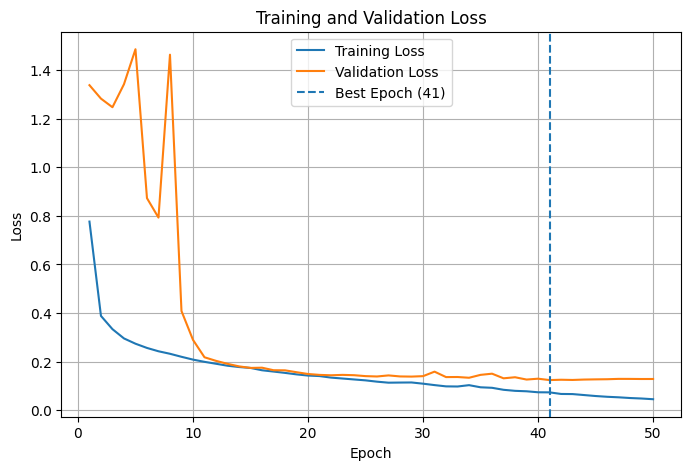

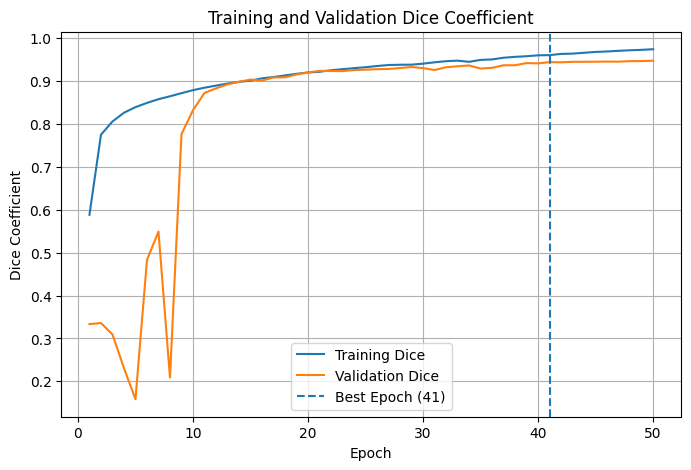

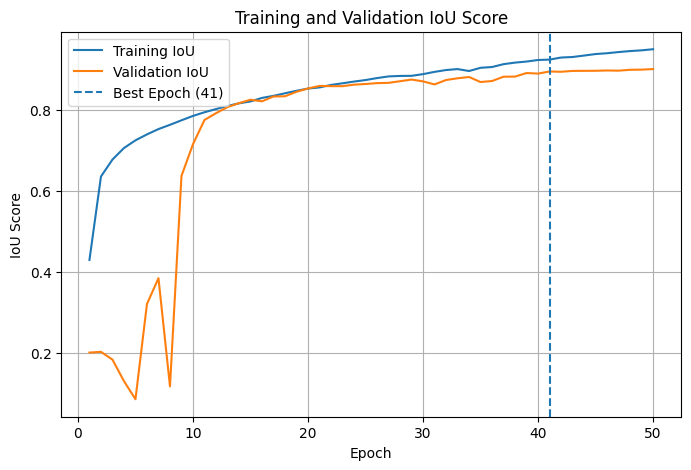


✅ Training history analysis completed.


In [32]:
import matplotlib.pyplot as plt
import numpy as np


# Get the number of epochs actually trained
epochs = range(1, len(history.history["loss"]) + 1)

# Identify best epoch based on validation loss
best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = np.min(history.history["val_loss"])

print("=" * 80)
print("TRAINING HISTORY SUMMARY")
print("=" * 80)

print(f"\nTotal epochs trained: {len(history.history['loss'])}")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

print(
    f"\nBest validation Dice: "
    f"{max(history.history['val_dice_coefficient']):.4f}"
)

print(
    f"Best validation IoU: "
    f"{max(history.history['val_iou_score']):.4f}"
)


# --------------------------------------------------
# LOSS CURVE
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()


# --------------------------------------------------
# DICE COEFFICIENT CURVE
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["dice_coefficient"],
    label="Training Dice"
)

plt.plot(
    epochs,
    history.history["val_dice_coefficient"],
    label="Validation Dice"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.title("Training and Validation Dice Coefficient")
plt.legend()
plt.grid()

plt.show()


# --------------------------------------------------
# IOU CURVE
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["iou_score"],
    label="Training IoU"
)

plt.plot(
    epochs,
    history.history["val_iou_score"],
    label="Validation IoU"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.title("Training and Validation IoU Score")
plt.legend()
plt.grid()

plt.show()

print("\n✅ Training history analysis completed.")

# Step 27: Load the Best Segmentation Model

The best U-Net checkpoint is loaded from disk.

The checkpoint was selected using the lowest validation loss during
training.

Custom loss and metric functions are provided when loading the model so
that the saved Keras model can be reconstructed correctly.

This model will be used for the final evaluation on the untouched test
dataset.

In [33]:
print("=" * 80)
print("LOADING BEST LUNG SEGMENTATION MODEL")
print("=" * 80)

best_unet_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score,
        "dice_loss": dice_loss
    }
)

print(f"\nModel loaded from:")
print(BEST_MODEL_PATH)

print(f"\nModel name: {best_unet_model.name}")
print(f"Input shape: {best_unet_model.input_shape}")
print(f"Output shape: {best_unet_model.output_shape}")

print(
    f"\nTotal parameters: "
    f"{best_unet_model.count_params():,}"
)

assert best_unet_model.input_shape == (None, 256, 256, 1)
assert best_unet_model.output_shape == (None, 256, 256, 1)

print("\n✅ Best segmentation model loaded successfully.")

LOADING BEST LUNG SEGMENTATION MODEL

Model loaded from:
/content/chest_xray_project/models/best_lung_segmentation_unet.keras

Model name: Lung_Segmentation_UNet
Input shape: (None, 256, 256, 1)
Output shape: (None, 256, 256, 1)

Total parameters: 7,768,353

✅ Best segmentation model loaded successfully.


# Step 28: Final Evaluation on the Untouched Test Set

The final lung segmentation model is evaluated on the untouched test
dataset.

The test dataset was not used during:

- Model training
- Data augmentation
- Validation monitoring
- Learning-rate adjustment
- Early stopping
- Model checkpoint selection

The following metrics are calculated:

- Combined segmentation loss
- Dice Coefficient
- Intersection over Union (IoU)

These results provide the final unbiased evaluation of the baseline
lung segmentation model.

In [34]:
print("=" * 80)
print("FINAL TEST SET EVALUATION")
print("=" * 80)

test_results = best_unet_model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True
)

print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)

for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

print(f"\nTest samples evaluated: 85")

print("\n✅ Final test evaluation completed successfully.")

FINAL TEST SET EVALUATION
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 728ms/step - dice_coefficient: 0.9342 - iou_score: 0.8785 - loss: 0.1562

FINAL TEST RESULTS
dice_coefficient: 0.9342
iou_score: 0.8785
loss: 0.1562

Test samples evaluated: 85

✅ Final test evaluation completed successfully.


# Step 29: Visual Evaluation of Lung Segmentation Predictions

The trained U-Net is visually evaluated using samples from the untouched
test dataset.

For each selected test image, the following are compared:

- Original chest X-ray
- Ground-truth lung mask
- Predicted probability mask
- Binary predicted lung mask

Predicted probabilities are converted into binary masks using a
threshold of 0.5.

This qualitative evaluation complements the quantitative Dice and IoU
scores obtained on the test dataset.

TEST PREDICTION VISUALIZATION

Number of samples displayed: 5
Prediction threshold: 0.5

Input shape: (5, 256, 256, 1)
Prediction shape: (5, 256, 256, 1)

Displaying:
1. Original Chest X-ray
2. Ground Truth Mask
3. Predicted Probability Mask
4. Binary Predicted Mask


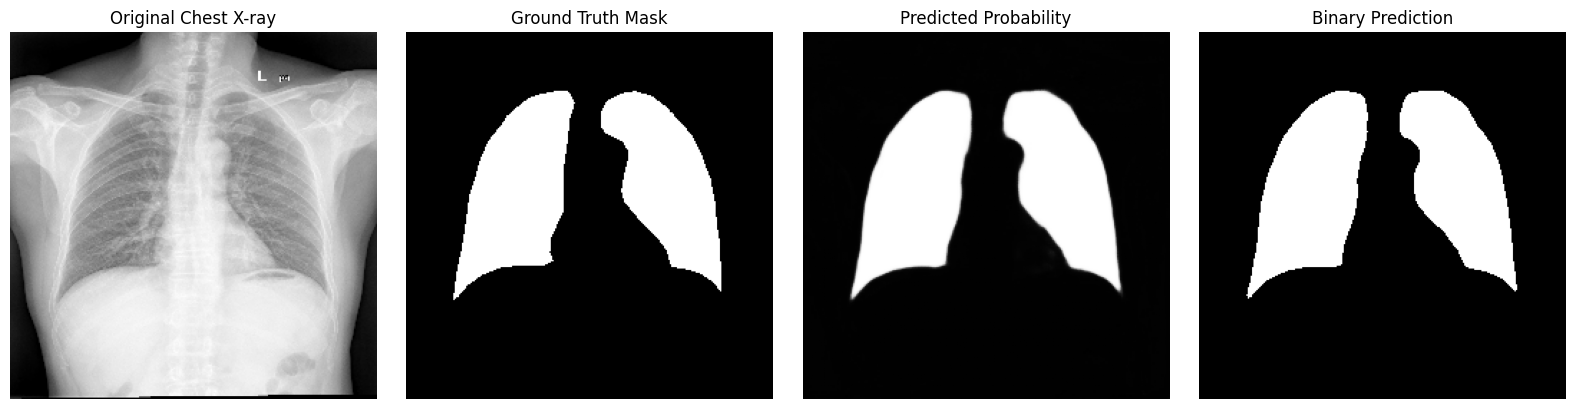

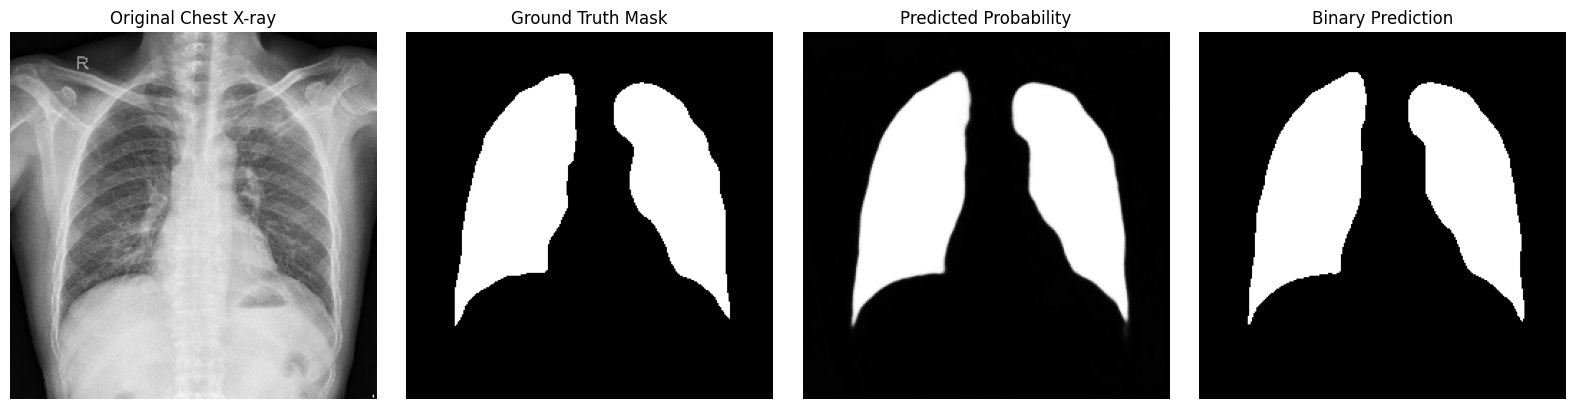

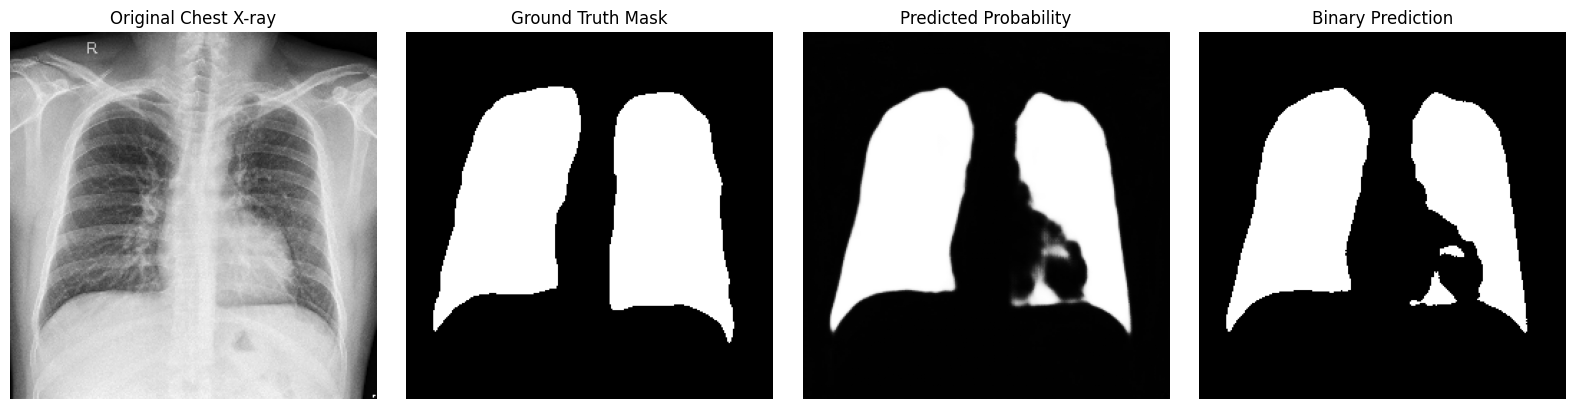

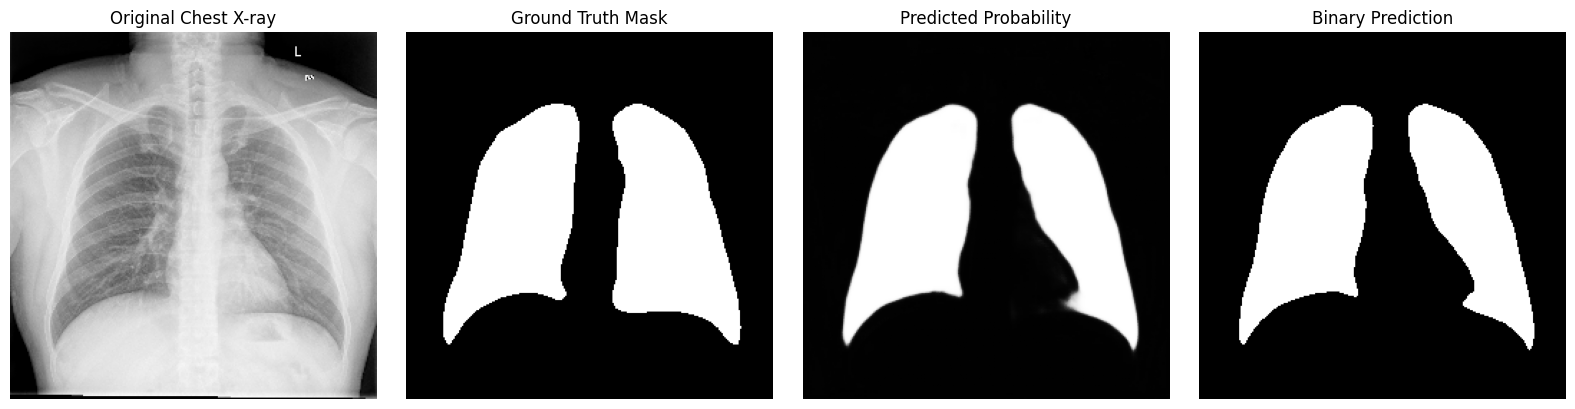

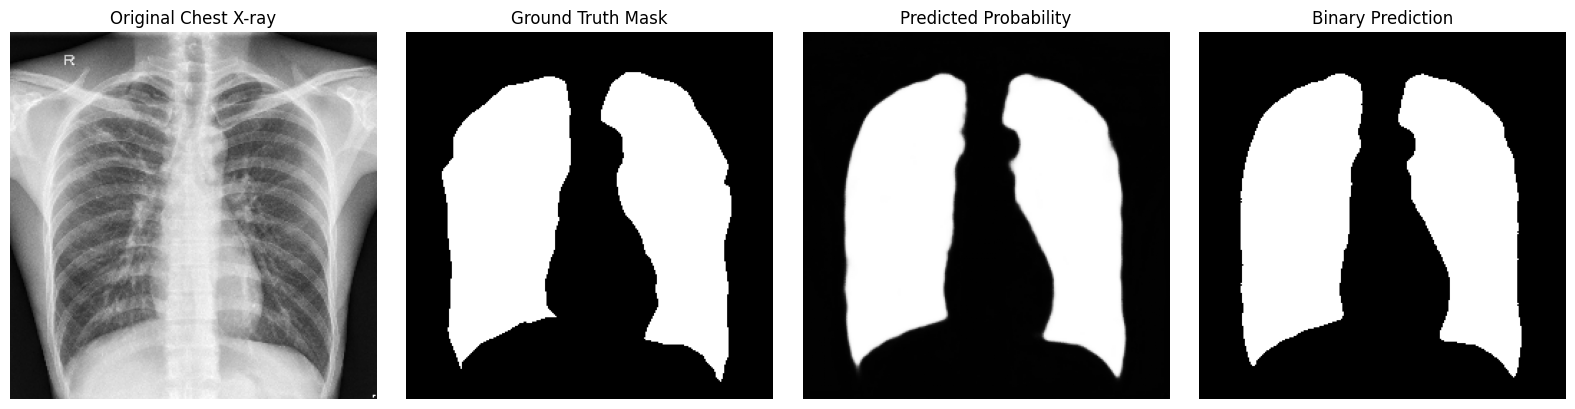


✅ Test prediction visualization completed successfully.


In [35]:
import matplotlib.pyplot as plt
import numpy as np


NUM_SAMPLES_TO_DISPLAY = 5
THRESHOLD = 0.5


# Collect test images and masks
test_images_list = []
test_masks_list = []

for images, masks in test_dataset.unbatch().take(NUM_SAMPLES_TO_DISPLAY):
    test_images_list.append(images.numpy())
    test_masks_list.append(masks.numpy())


test_images_array = np.array(test_images_list)
test_masks_array = np.array(test_masks_list)


# Generate predictions
predicted_probabilities = best_unet_model.predict(
    test_images_array,
    verbose=0
)

# Convert probabilities to binary masks
predicted_masks = (
    predicted_probabilities >= THRESHOLD
).astype(np.float32)


print("=" * 80)
print("TEST PREDICTION VISUALIZATION")
print("=" * 80)

print(f"\nNumber of samples displayed: {NUM_SAMPLES_TO_DISPLAY}")
print(f"Prediction threshold: {THRESHOLD}")

print(f"\nInput shape: {test_images_array.shape}")
print(f"Prediction shape: {predicted_probabilities.shape}")

print("\nDisplaying:")
print("1. Original Chest X-ray")
print("2. Ground Truth Mask")
print("3. Predicted Probability Mask")
print("4. Binary Predicted Mask")


# Create one figure per sample
for i in range(NUM_SAMPLES_TO_DISPLAY):

    plt.figure(figsize=(16, 4))

    # Original X-ray
    plt.subplot(1, 4, 1)
    plt.imshow(
        test_images_array[i].squeeze(),
        cmap="gray"
    )
    plt.title("Original Chest X-ray")
    plt.axis("off")


    # Ground truth
    plt.subplot(1, 4, 2)
    plt.imshow(
        test_masks_array[i].squeeze(),
        cmap="gray"
    )
    plt.title("Ground Truth Mask")
    plt.axis("off")


    # Predicted probability
    plt.subplot(1, 4, 3)
    plt.imshow(
        predicted_probabilities[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    plt.title("Predicted Probability")
    plt.axis("off")


    # Binary prediction
    plt.subplot(1, 4, 4)
    plt.imshow(
        predicted_masks[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    plt.title("Binary Prediction")
    plt.axis("off")


    plt.tight_layout()
    plt.show()


print("\n✅ Test prediction visualization completed successfully.")

# Step 30: Final Segmentation Prediction Validation

The final segmentation predictions are validated across the complete
untouched test dataset.

The validation checks:

- Prediction probability range
- Empty predicted masks
- Binary lung foreground coverage
- Ground-truth foreground coverage
- Differences between predicted and ground-truth lung coverage

This final validation ensures that the segmentation model produces
reasonable masks consistently across the entire test dataset.

In [36]:
import numpy as np
import tensorflow as tf
import pandas as pd


THRESHOLD = 0.5

print("=" * 80)
print("FINAL SEGMENTATION PREDICTION VALIDATION")
print("=" * 80)


# --------------------------------------------------
# Collect all test images and ground-truth masks
# --------------------------------------------------

all_test_images = []
all_test_masks = []

for images, masks in test_dataset:

    all_test_images.append(images.numpy())
    all_test_masks.append(masks.numpy())


all_test_images = np.concatenate(all_test_images, axis=0)
all_test_masks = np.concatenate(all_test_masks, axis=0)


# --------------------------------------------------
# Generate predictions for the complete test set
# --------------------------------------------------

all_pred_probabilities = best_unet_model.predict(
    all_test_images,
    verbose=0
)

all_pred_masks = (
    all_pred_probabilities >= THRESHOLD
).astype(np.float32)


# --------------------------------------------------
# Calculate foreground coverage
# --------------------------------------------------

ground_truth_coverage = np.mean(
    all_test_masks,
    axis=(1, 2, 3)
)

predicted_coverage = np.mean(
    all_pred_masks,
    axis=(1, 2, 3)
)

coverage_difference = (
    predicted_coverage - ground_truth_coverage
)


# --------------------------------------------------
# Check for empty predictions
# --------------------------------------------------

empty_predictions = np.sum(
    predicted_coverage == 0
)

empty_ground_truth_masks = np.sum(
    ground_truth_coverage == 0
)


# --------------------------------------------------
# Create summary
# --------------------------------------------------

print(f"\nTotal test samples: {len(all_test_images)}")

print("\nPrediction probability range:")
print(
    f"Minimum: "
    f"{all_pred_probabilities.min():.6f}"
)

print(
    f"Maximum: "
    f"{all_pred_probabilities.max():.6f}"
)


print("\nEmpty mask check:")
print(f"Empty predicted masks: {empty_predictions}")
print(f"Empty ground-truth masks: {empty_ground_truth_masks}")


print("\nGround-truth lung coverage:")
print(
    pd.Series(ground_truth_coverage).describe()
)


print("\nPredicted lung coverage:")
print(
    pd.Series(predicted_coverage).describe()
)


print("\nCoverage difference:")
print(
    pd.Series(coverage_difference).describe()
)


# --------------------------------------------------
# Validation assertions
# --------------------------------------------------

assert len(all_test_images) == 85
assert len(all_pred_masks) == 85
assert empty_predictions == 0
assert all_pred_probabilities.min() >= 0.0
assert all_pred_probabilities.max() <= 1.0

print("\n" + "=" * 80)
print("FINAL VALIDATION STATUS")
print("=" * 80)

print("\n✅ All 85 test predictions generated successfully.")
print("✅ No empty predicted masks detected.")
print("✅ Prediction probabilities are within the valid range [0, 1].")
print("✅ Final segmentation prediction validation completed successfully.")

FINAL SEGMENTATION PREDICTION VALIDATION

Total test samples: 85

Prediction probability range:
Minimum: 0.000512
Maximum: 0.999892

Empty mask check:
Empty predicted masks: 0
Empty ground-truth masks: 0

Ground-truth lung coverage:
count    85.000000
mean      0.249878
std       0.064054
min       0.098724
25%       0.208130
50%       0.246094
75%       0.286484
max       0.432785
dtype: float64

Predicted lung coverage:
count    85.000000
mean      0.242945
std       0.055053
min       0.101562
25%       0.204910
50%       0.241623
75%       0.280853
max       0.387131
dtype: float64

Coverage difference:
count    85.000000
mean     -0.006934
std       0.024805
min      -0.124603
25%      -0.009415
50%      -0.000488
75%       0.004501
max       0.060257
dtype: float64

FINAL VALIDATION STATUS

✅ All 85 test predictions generated successfully.
✅ No empty predicted masks detected.
✅ Prediction probabilities are within the valid range [0, 1].
✅ Final segmentation prediction validation 

# Step 31A: Rate-Limit-Safe Dataset Inspection

The Kaggle API returned HTTP 429, indicating that too many requests were
made in a short period.

The dataset inspection process is modified to:

- Inspect one dataset at a time
- Limit the number of pages retrieved
- Add delays between requests
- Retry automatically after rate-limit responses

The purpose of this step is to identify the dataset directory structure
and available diagnostic classes without downloading the full dataset.

In [38]:
import time
from collections import Counter


DATASET_TO_INSPECT = (
    "amanullahasraf/"
    "covid19-pneumonia-normal-chest-xray-pa-dataset"
)

MAX_RETRIES = 5
REQUEST_DELAY = 3
PAGE_SIZE = 100
MAX_PAGES = 10


def get_dataset_files_safely(dataset_id):

    all_files = []
    page_token = None

    for page_number in range(1, MAX_PAGES + 1):

        for attempt in range(1, MAX_RETRIES + 1):

            try:

                print(
                    f"Retrieving page {page_number} "
                    f"(attempt {attempt}/{MAX_RETRIES})..."
                )

                response = api.dataset_list_files(
                    dataset_id,
                    page_token=page_token,
                    page_size=PAGE_SIZE
                )

                files = getattr(
                    response,
                    "dataset_files",
                    None
                )

                if files is None:
                    files = getattr(
                        response,
                        "files",
                        []
                    )

                all_files.extend(files)

                page_token = getattr(
                    response,
                    "next_page_token",
                    None
                )

                print(
                    f"✓ Retrieved {len(files)} files"
                )

                break

            except Exception as e:

                error_message = str(e)

                if "429" in error_message:

                    wait_time = REQUEST_DELAY * attempt

                    print(
                        f"⚠️ Rate limit reached. "
                        f"Waiting {wait_time} seconds..."
                    )

                    time.sleep(wait_time)

                else:
                    raise e

        else:
            print(
                "\n❌ Maximum retries reached."
            )
            break

        if not page_token:
            print(
                "\nNo more pages available."
            )
            break

        time.sleep(REQUEST_DELAY)

    return all_files


print("=" * 100)
print("RATE-LIMIT-SAFE DATASET INSPECTION")
print("=" * 100)

print(f"\nDataset: {DATASET_TO_INSPECT}\n")

dataset_files = get_dataset_files_safely(
    DATASET_TO_INSPECT
)


# --------------------------------------------------
# Extract file names
# --------------------------------------------------

file_names = []

for file_obj in dataset_files:

    file_name = getattr(
        file_obj,
        "name",
        None
    )

    if file_name:
        file_names.append(file_name)


print("\n" + "=" * 100)
print("DATASET STRUCTURE ANALYSIS")
print("=" * 100)

print(
    f"\nFiles retrieved for inspection: "
    f"{len(file_names)}"
)


# --------------------------------------------------
# Analyze parent directories
# --------------------------------------------------

directory_counter = Counter()

for file_name in file_names:

    parts = file_name.split("/")

    if len(parts) > 1:
        directory = "/".join(parts[:-1])
    else:
        directory = "[ROOT]"

    directory_counter[directory] += 1


print("\nDetected directories:")

for directory, count in directory_counter.most_common(20):
    print(f" - {directory}: {count}")


# --------------------------------------------------
# Analyze file types
# --------------------------------------------------

extension_counter = Counter()

for file_name in file_names:

    if "." in file_name:

        extension = (
            file_name
            .rsplit(".", 1)[-1]
            .lower()
        )

        extension_counter[extension] += 1


print("\nFile types:")

for extension, count in extension_counter.items():
    print(f" - .{extension}: {count}")


# --------------------------------------------------
# Show examples
# --------------------------------------------------

print("\nFirst 20 files:")

for file_name in file_names[:20]:
    print(f" - {file_name}")


print("\n" + "=" * 100)
print("INSPECTION COMPLETED")
print("=" * 100)

RATE-LIMIT-SAFE DATASET INSPECTION

Dataset: amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset

Retrieving page 1 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 2 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 3 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 4 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 5 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 6 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 7 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 8 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 9 (attempt 1/5)...
✓ Retrieved 100 files
Retrieving page 10 (attempt 1/5)...
✓ Retrieved 100 files

DATASET STRUCTURE ANALYSIS

Files retrieved for inspection: 1000

Detected directories:
 - covid: 1000

File types:
 - .jpeg: 199
 - .jpg: 451
 - .png: 313
 - .jfif: 37

First 20 files:
 - covid/001.jpeg
 - covid/002.jpeg
 - covid/003.jpeg
 - covid/004.jpeg
 - covid/005.jpeg
 - covid/006.jpeg
 - covid/007.jpg
 - covid/

# Step 31B: Classification Dataset Class Discovery

The initial inspection retrieved 1,000 files, all belonging to the `covid`
directory.

This step retrieves the remaining dataset file metadata and identifies all
top-level class directories.

The objective is to determine:

- All available diagnostic classes
- Number of files in each class directory
- Whether the dataset structure is suitable for the classification pipeline

In [39]:
import time
from collections import Counter

DATASET_TO_INSPECT = (
    "amanullahasraf/"
    "covid19-pneumonia-normal-chest-xray-pa-dataset"
)

PAGE_SIZE = 100
REQUEST_DELAY = 2
MAX_RETRIES = 5


def get_all_files_with_retry(dataset_id):

    all_file_names = []
    page_token = None
    page_number = 1

    while True:

        success = False

        for attempt in range(1, MAX_RETRIES + 1):

            try:

                print(
                    f"Retrieving page {page_number} "
                    f"(attempt {attempt}/{MAX_RETRIES})..."
                )

                response = api.dataset_list_files(
                    dataset_id,
                    page_token=page_token,
                    page_size=PAGE_SIZE
                )

                files = getattr(
                    response,
                    "dataset_files",
                    None
                )

                if files is None:
                    files = getattr(
                        response,
                        "files",
                        []
                    )

                current_file_names = []

                for file_obj in files:

                    file_name = getattr(
                        file_obj,
                        "name",
                        None
                    )

                    if file_name:
                        current_file_names.append(file_name)

                all_file_names.extend(current_file_names)

                print(
                    f"✓ Retrieved {len(current_file_names)} files "
                    f"| Total so far: {len(all_file_names)}"
                )

                page_token = getattr(
                    response,
                    "next_page_token",
                    None
                )

                success = True
                break

            except Exception as e:

                if "429" in str(e):

                    wait_time = REQUEST_DELAY * attempt * 2

                    print(
                        f"⚠️ Rate limit reached. "
                        f"Waiting {wait_time} seconds..."
                    )

                    time.sleep(wait_time)

                else:
                    raise e


        if not success:

            print("\n❌ Maximum retries reached.")
            break


        if not page_token:

            print("\n✓ No more pages available.")
            break


        page_number += 1

        time.sleep(REQUEST_DELAY)


    return all_file_names


print("=" * 100)
print("FULL CLASS DIRECTORY DISCOVERY")
print("=" * 100)

file_names = get_all_files_with_retry(
    DATASET_TO_INSPECT
)


# --------------------------------------------------
# Identify top-level directories
# --------------------------------------------------

top_level_counter = Counter()

for file_name in file_names:

    parts = file_name.split("/")

    if len(parts) > 1:
        top_level_directory = parts[0]
    else:
        top_level_directory = "[ROOT]"

    top_level_counter[top_level_directory] += 1


print("\n" + "=" * 100)
print("CLASS DIRECTORY SUMMARY")
print("=" * 100)

print(f"\nTotal files retrieved: {len(file_names)}")

for directory, count in top_level_counter.items():
    print(f" - {directory}: {count} files")


# --------------------------------------------------
# Show transition points between directories
# --------------------------------------------------

print("\n" + "=" * 100)
print("DIRECTORY TRANSITIONS")
print("=" * 100)

previous_directory = None

for index, file_name in enumerate(file_names):

    current_directory = file_name.split("/")[0]

    if current_directory != previous_directory:

        print(
            f"\nFile index {index + 1}: "
            f"{current_directory}"
        )

        print(f"First file: {file_name}")

        previous_directory = current_directory


print("\n" + "=" * 100)
print("CLASS DISCOVERY COMPLETED")
print("=" * 100)

FULL CLASS DIRECTORY DISCOVERY
Retrieving page 1 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 100
Retrieving page 2 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 200
Retrieving page 3 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 300
Retrieving page 4 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 400
Retrieving page 5 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 500
Retrieving page 6 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 600
Retrieving page 7 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 700
Retrieving page 8 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 800
Retrieving page 9 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 900
Retrieving page 10 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 1000
Retrieving page 11 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 1100
Retrieving page 12 (attempt 1/5)...
✓ Retrieved 100 files | Total so far: 1200
Retrieving page 13 (attempt 1/5)...
✓ R

# Step 32: Download the Classification Dataset

The selected classification dataset contains three balanced classes:

- COVID-19: 2,313 images
- Normal: 2,313 images
- Pneumonia: 2,313 images

Total images: 6,939

The dataset will be downloaded into the project's raw download directory.

The raw dataset will remain unchanged. All subsequent preprocessing and
dataset preparation steps will create separate derived datasets.

In [40]:
from pathlib import Path

# --------------------------------------------------
# Classification dataset configuration
# --------------------------------------------------

CLASSIFICATION_SOURCE_DATASET = (
    "amanullahasraf/"
    "covid19-pneumonia-normal-chest-xray-pa-dataset"
)

RAW_CLASSIFICATION_DIR = (
    PROJECT_ROOT
    / "raw_downloads"
    / "classification"
)

RAW_CLASSIFICATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 80)
print("DOWNLOADING CLASSIFICATION DATASET")
print("=" * 80)

print(f"\nDataset:")
print(CLASSIFICATION_SOURCE_DATASET)

print(f"\nDownload location:")
print(RAW_CLASSIFICATION_DIR)


# --------------------------------------------------
# Download and extract dataset
# --------------------------------------------------

api.dataset_download_files(
    CLASSIFICATION_SOURCE_DATASET,
    path=str(RAW_CLASSIFICATION_DIR),
    unzip=True
)


print("\n" + "=" * 80)
print("DOWNLOAD COMPLETED")
print("=" * 80)

print(f"\nDataset downloaded to:")
print(RAW_CLASSIFICATION_DIR)

print("\nExpected classes:")
print(" - covid")
print(" - normal")
print(" - pneumonia")

print("\nExpected total images: 6,939")

print("\n✅ Classification dataset downloaded successfully.")

DOWNLOADING CLASSIFICATION DATASET

Dataset:
amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset

Download location:
/content/chest_xray_project/raw_downloads/classification
Dataset URL: https://www.kaggle.com/datasets/amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset

DOWNLOAD COMPLETED

Dataset downloaded to:
/content/chest_xray_project/raw_downloads/classification

Expected classes:
 - covid
 - normal
 - pneumonia

Expected total images: 6,939

✅ Classification dataset downloaded successfully.


# Step 33: Classification Dataset Integrity Verification

The downloaded classification dataset is verified locally before any
preprocessing or model training.

The verification checks:

- Expected class directories
- Number of images per class
- Total image count
- Image file formats
- Image readability
- Image dimensions

The raw dataset remains unchanged during this process.

Only valid and readable images will be considered for subsequent
dataset preparation.

In [41]:
from pathlib import Path
from collections import Counter
from PIL import Image
import pandas as pd


print("=" * 100)
print("CLASSIFICATION DATASET INTEGRITY REPORT")
print("=" * 100)


# --------------------------------------------------
# Configuration
# --------------------------------------------------

EXPECTED_CLASSES = {
    "covid",
    "normal",
    "pneumonia"
}

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".jfif"
}


# --------------------------------------------------
# Locate class directories
# --------------------------------------------------

class_directories = {}

for class_name in EXPECTED_CLASSES:

    class_path = RAW_CLASSIFICATION_DIR / class_name

    if class_path.exists() and class_path.is_dir():
        class_directories[class_name] = class_path


print("\nExpected classes:")
for class_name in sorted(EXPECTED_CLASSES):
    print(f" - {class_name}")


print("\nDetected class directories:")
for class_name in sorted(class_directories):
    print(f" - {class_name}: {class_directories[class_name]}")


missing_classes = (
    EXPECTED_CLASSES
    - set(class_directories.keys())
)


if missing_classes:
    print("\n❌ Missing expected classes:")
    for class_name in sorted(missing_classes):
        print(f" - {class_name}")
else:
    print("\n✅ All expected classes found.")


# --------------------------------------------------
# Scan images
# --------------------------------------------------

class_counts = Counter()
extension_counts = Counter()
image_sizes = Counter()

corrupted_images = []
all_image_files = []


for class_name, class_path in class_directories.items():

    for file_path in class_path.rglob("*"):

        if (
            file_path.is_file()
            and file_path.suffix.lower()
            in SUPPORTED_EXTENSIONS
        ):

            try:

                with Image.open(file_path) as image:

                    image.verify()


                # Reopen after verify() to safely inspect size
                with Image.open(file_path) as image:

                    image_size = image.size


                class_counts[class_name] += 1
                extension_counts[
                    file_path.suffix.lower()
                ] += 1

                image_sizes[image_size] += 1

                all_image_files.append(
                    (class_name, file_path)
                )


            except Exception as e:

                corrupted_images.append(
                    {
                        "class": class_name,
                        "file": str(file_path),
                        "error": str(e)
                    }
                )


# --------------------------------------------------
# Report class distribution
# --------------------------------------------------

print("\n" + "=" * 100)
print("CLASS DISTRIBUTION")
print("=" * 100)

for class_name in sorted(EXPECTED_CLASSES):

    count = class_counts[class_name]

    print(
        f"{class_name.capitalize():<15}: "
        f"{count}"
    )


total_valid_images = sum(
    class_counts.values()
)

print("-" * 50)
print(
    f"{'Total valid images':<15}: "
    f"{total_valid_images}"
)


# --------------------------------------------------
# File type distribution
# --------------------------------------------------

print("\n" + "=" * 100)
print("IMAGE FILE TYPES")
print("=" * 100)

for extension, count in sorted(
    extension_counts.items()
):

    print(f"{extension}: {count}")


# --------------------------------------------------
# Image dimension distribution
# --------------------------------------------------

print("\n" + "=" * 100)
print("MOST COMMON IMAGE DIMENSIONS")
print("=" * 100)

for image_size, count in image_sizes.most_common(15):

    print(
        f"{image_size}: {count}"
    )


# --------------------------------------------------
# Corruption report
# --------------------------------------------------

print("\n" + "=" * 100)
print("IMAGE READABILITY CHECK")
print("=" * 100)

print(
    f"\nValid readable images: "
    f"{total_valid_images}"
)

print(
    f"Corrupted/unreadable images: "
    f"{len(corrupted_images)}"
)


if corrupted_images:

    print("\nSample corrupted images:")

    for item in corrupted_images[:10]:

        print(
            f" - [{item['class']}] "
            f"{item['file']}"
        )


# --------------------------------------------------
# Final validation
# --------------------------------------------------

assert not missing_classes, (
    "One or more expected classes are missing."
)

assert total_valid_images > 0, (
    "No valid images were found."
)


print("\n" + "=" * 100)
print("FINAL DATASET VALIDATION STATUS")
print("=" * 100)

if len(corrupted_images) == 0:

    print("\n✅ All detected images are readable.")

else:

    print(
        f"\n⚠️ {len(corrupted_images)} "
        f"corrupted images detected."
    )


print(
    f"✅ Total valid images: "
    f"{total_valid_images}"
)

print(
    "✅ Classification dataset integrity "
    "verification completed successfully."
)

CLASSIFICATION DATASET INTEGRITY REPORT

Expected classes:
 - covid
 - normal
 - pneumonia

Detected class directories:
 - covid: /content/chest_xray_project/raw_downloads/classification/covid
 - normal: /content/chest_xray_project/raw_downloads/classification/normal
 - pneumonia: /content/chest_xray_project/raw_downloads/classification/pneumonia

✅ All expected classes found.

CLASS DISTRIBUTION
Covid          : 2313
Normal         : 2313
Pneumonia      : 2313
--------------------------------------------------
Total valid images: 6939

IMAGE FILE TYPES
.jfif: 37
.jpeg: 2691
.jpg: 1725
.png: 2486

MOST COMMON IMAGE DIMENSIONS
(1024, 1024): 3138
(2000, 2000): 84
(1200, 1200): 36
(480, 480): 23
(3050, 2539): 17
(640, 524): 15
(1024, 842): 10
(640, 640): 9
(2836, 2336): 7
(1024, 843): 7
(2498, 1971): 6
(640, 547): 6
(640, 591): 5
(640, 552): 5
(640, 589): 5

IMAGE READABILITY CHECK

Valid readable images: 6939
Corrupted/unreadable images: 0

FINAL DATASET VALIDATION STATUS

✅ All detected

# Step 34: Create Classification Dataset Manifest

A dataset manifest is created containing every valid image and its
corresponding diagnostic class.

The manifest provides a reproducible record of:

- Image file path
- Class name
- Numerical class label
- Original file extension

The dataset contains three balanced classes:

- COVID
- Normal
- Pneumonia

This manifest will be used for stratified train, validation, and test
splitting in the next step.

In [42]:
import pandas as pd
from pathlib import Path


print("=" * 100)
print("CREATING CLASSIFICATION DATASET MANIFEST")
print("=" * 100)


# --------------------------------------------------
# Class configuration
# --------------------------------------------------

CLASS_NAMES = [
    "covid",
    "normal",
    "pneumonia"
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".jfif"
}


# --------------------------------------------------
# Build manifest records
# --------------------------------------------------

records = []

for class_name in CLASS_NAMES:

    class_directory = (
        RAW_CLASSIFICATION_DIR / class_name
    )

    for file_path in sorted(class_directory.rglob("*")):

        if (
            file_path.is_file()
            and file_path.suffix.lower()
            in SUPPORTED_EXTENSIONS
        ):

            records.append(
                {
                    "filepath": str(file_path),
                    "class_name": class_name,
                    "class_index": CLASS_TO_INDEX[class_name],
                    "file_extension": file_path.suffix.lower()
                }
            )


# --------------------------------------------------
# Create DataFrame
# --------------------------------------------------

classification_df = pd.DataFrame(records)


# --------------------------------------------------
# Validate manifest
# --------------------------------------------------

print(f"\nTotal images in manifest: {len(classification_df)}")

print("\nClass-to-index mapping:")

for class_name, class_index in CLASS_TO_INDEX.items():
    print(f" - {class_name}: {class_index}")


print("\nClass distribution:")

class_distribution = (
    classification_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print(class_distribution)


print("\nSample records:")
print(
    classification_df.head()
)


# --------------------------------------------------
# Save manifest
# --------------------------------------------------

MANIFEST_DIR = PROJECT_ROOT / "data" / "classification"
MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_PATH = (
    MANIFEST_DIR
    / "classification_manifest.csv"
)

classification_df.to_csv(
    MANIFEST_PATH,
    index=False
)


# --------------------------------------------------
# Final validation
# --------------------------------------------------

assert len(classification_df) == 6939
assert set(
    classification_df["class_name"].unique()
) == set(CLASS_NAMES)

assert (
    classification_df["filepath"]
    .duplicated()
    .sum()
) == 0


print("\n" + "=" * 100)
print("MANIFEST CREATION STATUS")
print("=" * 100)

print(
    f"\nManifest saved to:\n{MANIFEST_PATH}"
)

print("\nTotal unique images: 6,939")
print("Duplicate file paths: 0")

print(
    "\n✅ Classification dataset manifest "
    "created successfully."
)

CREATING CLASSIFICATION DATASET MANIFEST

Total images in manifest: 6939

Class-to-index mapping:
 - covid: 0
 - normal: 1
 - pneumonia: 2

Class distribution:
class_name
covid        2313
normal       2313
pneumonia    2313
Name: count, dtype: int64

Sample records:
                                            filepath class_name  class_index  \
0  /content/chest_xray_project/raw_downloads/clas...      covid            0   
1  /content/chest_xray_project/raw_downloads/clas...      covid            0   
2  /content/chest_xray_project/raw_downloads/clas...      covid            0   
3  /content/chest_xray_project/raw_downloads/clas...      covid            0   
4  /content/chest_xray_project/raw_downloads/clas...      covid            0   

  file_extension  
0          .jpeg  
1          .jpeg  
2          .jpeg  
3          .jpeg  
4          .jpeg  

MANIFEST CREATION STATUS

Manifest saved to:
/content/chest_xray_project/data/classification/classification_manifest.csv

Total unique i

# Step 35: Stratified Train, Validation, and Test Split

The classification dataset is divided into three mutually exclusive subsets:

- Training: 70%
- Validation: 15%
- Test: 15%

A stratified splitting strategy is used to preserve the distribution of
the three diagnostic classes in each subset.

The split is performed using a fixed random seed to ensure
reproducibility.

No image file path is allowed to appear in more than one subset.

In [43]:
from sklearn.model_selection import train_test_split


print("=" * 100)
print("CLASSIFICATION DATASET SPLIT")
print("=" * 100)


# --------------------------------------------------
# Configuration
# --------------------------------------------------

RANDOM_SEED = 42

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15


# --------------------------------------------------
# First split:
# Training = 70%
# Temporary = 30%
# --------------------------------------------------

train_df, temp_df = train_test_split(
    classification_df,
    test_size=(
        VALIDATION_RATIO + TEST_RATIO
    ),
    stratify=classification_df["class_name"],
    random_state=RANDOM_SEED
)


# --------------------------------------------------
# Second split:
# Temporary 30% -> Validation 15% + Test 15%
# --------------------------------------------------

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=RANDOM_SEED
)


# --------------------------------------------------
# Reset indices
# --------------------------------------------------

train_df = train_df.reset_index(drop=True)

validation_df = validation_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)


# --------------------------------------------------
# Display split sizes
# --------------------------------------------------

print("\nSplit sizes:")

print(
    f"Training samples:   "
    f"{len(train_df)}"
)

print(
    f"Validation samples: "
    f"{len(validation_df)}"
)

print(
    f"Test samples:       "
    f"{len(test_df)}"
)


print("\nPercentage distribution:")

print(
    f"Training:   "
    f"{len(train_df) / len(classification_df) * 100:.2f}%"
)

print(
    f"Validation: "
    f"{len(validation_df) / len(classification_df) * 100:.2f}%"
)

print(
    f"Test:       "
    f"{len(test_df) / len(classification_df) * 100:.2f}%"
)


# --------------------------------------------------
# Class distribution in each subset
# --------------------------------------------------

print("\n" + "=" * 100)
print("CLASS DISTRIBUTION BY SUBSET")
print("=" * 100)


def display_distribution(name, dataframe):

    print(f"\n{name}:")

    distribution = (
        dataframe["class_name"]
        .value_counts()
        .reindex(CLASS_NAMES)
    )

    for class_name, count in distribution.items():

        percentage = (
            count / len(dataframe)
        ) * 100

        print(
            f" - {class_name:<10}: "
            f"{count:4d} "
            f"({percentage:.2f}%)"
        )


display_distribution(
    "Training Set",
    train_df
)

display_distribution(
    "Validation Set",
    validation_df
)

display_distribution(
    "Test Set",
    test_df
)


# --------------------------------------------------
# Verify no overlap
# --------------------------------------------------

train_paths = set(train_df["filepath"])

validation_paths = set(
    validation_df["filepath"]
)

test_paths = set(test_df["filepath"])


train_validation_overlap = (
    train_paths & validation_paths
)

train_test_overlap = (
    train_paths & test_paths
)

validation_test_overlap = (
    validation_paths & test_paths
)


assert len(train_validation_overlap) == 0
assert len(train_test_overlap) == 0
assert len(validation_test_overlap) == 0


# --------------------------------------------------
# Verify complete coverage
# --------------------------------------------------

all_split_paths = (
    train_paths
    | validation_paths
    | test_paths
)

original_paths = set(
    classification_df["filepath"]
)

assert all_split_paths == original_paths


# --------------------------------------------------
# Save split manifests
# --------------------------------------------------

SPLIT_DIR = (
    PROJECT_ROOT
    / "data"
    / "classification"
    / "splits"
)

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


TRAIN_MANIFEST_PATH = (
    SPLIT_DIR
    / "train_manifest.csv"
)

VALIDATION_MANIFEST_PATH = (
    SPLIT_DIR
    / "validation_manifest.csv"
)

TEST_MANIFEST_PATH = (
    SPLIT_DIR
    / "test_manifest.csv"
)


train_df.to_csv(
    TRAIN_MANIFEST_PATH,
    index=False
)

validation_df.to_csv(
    VALIDATION_MANIFEST_PATH,
    index=False
)

test_df.to_csv(
    TEST_MANIFEST_PATH,
    index=False
)


# --------------------------------------------------
# Final validation
# --------------------------------------------------

print("\n" + "=" * 100)
print("SPLIT VALIDATION STATUS")
print("=" * 100)

print(
    f"\nTotal original samples: "
    f"{len(classification_df)}"
)

print(
    f"Total split samples:    "
    f"{len(train_df) + len(validation_df) + len(test_df)}"
)

print("\nTrain-validation overlap: 0")
print("Train-test overlap:       0")
print("Validation-test overlap:  0")

print("\nSaved manifests:")

print(f" - {TRAIN_MANIFEST_PATH}")
print(f" - {VALIDATION_MANIFEST_PATH}")
print(f" - {TEST_MANIFEST_PATH}")

print(
    "\n✅ Stratified dataset split "
    "completed successfully."
)

CLASSIFICATION DATASET SPLIT

Split sizes:
Training samples:   4857
Validation samples: 1041
Test samples:       1041

Percentage distribution:
Training:   70.00%
Validation: 15.00%
Test:       15.00%

CLASS DISTRIBUTION BY SUBSET

Training Set:
 - covid     : 1619 (33.33%)
 - normal    : 1619 (33.33%)
 - pneumonia : 1619 (33.33%)

Validation Set:
 - covid     :  347 (33.33%)
 - normal    :  347 (33.33%)
 - pneumonia :  347 (33.33%)

Test Set:
 - covid     :  347 (33.33%)
 - normal    :  347 (33.33%)
 - pneumonia :  347 (33.33%)

SPLIT VALIDATION STATUS

Total original samples: 6939
Total split samples:    6939

Train-validation overlap: 0
Train-test overlap:       0
Validation-test overlap:  0

Saved manifests:
 - /content/chest_xray_project/data/classification/splits/train_manifest.csv
 - /content/chest_xray_project/data/classification/splits/validation_manifest.csv
 - /content/chest_xray_project/data/classification/splits/test_manifest.csv

✅ Stratified dataset split completed succe

# Step 36: Classification Image Preprocessing

The classification dataset contains images with different:

- Dimensions
- Aspect ratios
- File formats
- Original resolutions

A unified preprocessing pipeline is created to ensure that every image
has a consistent representation before entering the classification model.

Each image will:

1. Be loaded from disk
2. Be decoded into a three-channel image
3. Be resized to 224 × 224 pixels
4. Be converted to `float32`
5. Be normalized to the range [0, 1]

The diagnostic labels remain unchanged:

- COVID → 0
- Normal → 1
- Pneumonia → 2

In [44]:
import tensorflow as tf
import numpy as np


print("=" * 100)
print("CLASSIFICATION PREPROCESSING CONFIGURATION")
print("=" * 100)


# --------------------------------------------------
# Configuration
# --------------------------------------------------

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_CHANNELS = 3

AUTOTUNE = tf.data.AUTOTUNE


# --------------------------------------------------
# Image loading and preprocessing
# --------------------------------------------------

def load_and_preprocess_classification_image(
    filepath,
    label
):

    # Read image file
    image = tf.io.read_file(filepath)


    # Decode image into 3 channels
    image = tf.io.decode_image(
        image,
        channels=IMAGE_CHANNELS,
        expand_animations=False
    )


    # Set static shape after decode_image
    image.set_shape(
        [None, None, IMAGE_CHANNELS]
    )


    # Convert to float32
    image = tf.cast(
        image,
        tf.float32
    )


    # Resize image
    image = tf.image.resize(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH]
    )


    # Normalize pixel values
    image = image / 255.0


    return image, label


print("\nPreprocessing configuration:")

print(
    f"Image size: "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH}"
)

print(
    f"Image channels: "
    f"{IMAGE_CHANNELS}"
)

print("Output dtype: float32")
print("Pixel range: [0, 1]")

print("\nClass mapping:")

for class_name, class_index in CLASS_TO_INDEX.items():
    print(
        f" - {class_name}: "
        f"{class_index}"
    )


# --------------------------------------------------
# Validate preprocessing on sample images
# --------------------------------------------------

sample_records = classification_df.sample(
    n=3,
    random_state=RANDOM_SEED
)


print("\n" + "=" * 100)
print("PREPROCESSING VALIDATION")
print("=" * 100)


for _, row in sample_records.iterrows():

    filepath = row["filepath"]
    label = row["class_index"]


    processed_image, processed_label = (
        load_and_preprocess_classification_image(
            tf.constant(filepath),
            tf.constant(label)
        )
    )


    print(
        f"\nClass: {row['class_name']}"
    )

    print(
        f"Original file: "
        f"{Path(filepath).name}"
    )

    print(
        f"Processed shape: "
        f"{processed_image.shape}"
    )

    print(
        f"Label: "
        f"{processed_label.numpy()}"
    )

    print(
        f"Value range: "
        f"{tf.reduce_min(processed_image).numpy():.4f} "
        f"to "
        f"{tf.reduce_max(processed_image).numpy():.4f}"
    )


# --------------------------------------------------
# Final assertions
# --------------------------------------------------

assert processed_image.shape == (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    IMAGE_CHANNELS
)

assert processed_image.dtype == tf.float32

assert (
    tf.reduce_min(processed_image).numpy() >= 0.0
)

assert (
    tf.reduce_max(processed_image).numpy() <= 1.0
)


print("\n" + "=" * 100)
print("PREPROCESSING VALIDATION STATUS")
print("=" * 100)

print(
    "\nProcessed image shape: "
    f"({IMAGE_HEIGHT}, "
    f"{IMAGE_WIDTH}, "
    f"{IMAGE_CHANNELS})"
)

print("Data type: float32")
print("Pixel range: [0, 1]")

print(
    "\n✅ Classification preprocessing "
    "pipeline validation passed."
)

CLASSIFICATION PREPROCESSING CONFIGURATION

Preprocessing configuration:
Image size: 224 × 224
Image channels: 3
Output dtype: float32
Pixel range: [0, 1]

Class mapping:
 - covid: 0
 - normal: 1
 - pneumonia: 2

PREPROCESSING VALIDATION

Class: normal
Original file: IM-0512-0001.jpeg
Processed shape: (224, 224, 3)
Label: 1
Value range: 0.0000 to 1.0000

Class: pneumonia
Original file: person1252_virus_2124.jpeg
Processed shape: (224, 224, 3)
Label: 2
Value range: 0.0000 to 1.0000

Class: pneumonia
Original file: person81_virus_153.jpeg
Processed shape: (224, 224, 3)
Label: 2
Value range: 0.0000 to 1.0000

PREPROCESSING VALIDATION STATUS

Processed image shape: (224, 224, 3)
Data type: float32
Pixel range: [0, 1]

✅ Classification preprocessing pipeline validation passed.


# Step 37: Optimized tf.data Classification Pipeline

The train, validation, and test manifests are converted into TensorFlow
`tf.data.Dataset` pipelines.

The pipeline performs:

1. Creation of datasets from image file paths and labels
2. Image loading and preprocessing
3. Shuffling of training samples
4. Batching
5. Prefetching for improved training throughput

Validation and test datasets are not shuffled to ensure deterministic
evaluation and reproducible predictions.

In [45]:
print("=" * 100)
print("BUILDING CLASSIFICATION TF.DATA PIPELINES")
print("=" * 100)


# --------------------------------------------------
# Configuration
# --------------------------------------------------

CLASSIFICATION_BATCH_SIZE = 32

SHUFFLE_BUFFER_SIZE = len(train_df)


# --------------------------------------------------
# Helper function
# --------------------------------------------------

def create_classification_dataset(
    dataframe,
    training=False
):

    filepaths = dataframe["filepath"].values

    labels = (
        dataframe["class_index"]
        .values
        .astype(np.int32)
    )


    dataset = tf.data.Dataset.from_tensor_slices(
        (
            filepaths,
            labels
        )
    )


    # Shuffle training data only
    if training:

        dataset = dataset.shuffle(
            buffer_size=SHUFFLE_BUFFER_SIZE,
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )


    # Load and preprocess images
    dataset = dataset.map(
        load_and_preprocess_classification_image,
        num_parallel_calls=AUTOTUNE
    )


    # Batch samples
    dataset = dataset.batch(
        CLASSIFICATION_BATCH_SIZE
    )


    # Prefetch batches
    dataset = dataset.prefetch(
        AUTOTUNE
    )


    return dataset


# --------------------------------------------------
# Create datasets
# --------------------------------------------------

train_ds = create_classification_dataset(
    train_df,
    training=True
)

validation_ds = create_classification_dataset(
    validation_df,
    training=False
)

test_ds = create_classification_dataset(
    test_df,
    training=False
)


# --------------------------------------------------
# Validate datasets
# --------------------------------------------------

print("\nDataset sample counts:")

print(
    f"Training samples:   {len(train_df)}"
)

print(
    f"Validation samples: {len(validation_df)}"
)

print(
    f"Test samples:       {len(test_df)}"
)


print("\nBatch counts:")

print(
    f"Training batches:   "
    f"{len(train_ds)}"
)

print(
    f"Validation batches: "
    f"{len(validation_ds)}"
)

print(
    f"Test batches:       "
    f"{len(test_ds)}"
)


# --------------------------------------------------
# Inspect one training batch
# --------------------------------------------------

for images, labels in train_ds.take(1):

    print("\nFirst training batch:")

    print(
        f"Images shape: "
        f"{images.shape}"
    )

    print(
        f"Images dtype: "
        f"{images.dtype}"
    )

    print(
        f"Labels shape: "
        f"{labels.shape}"
    )

    print(
        f"Labels dtype: "
        f"{labels.dtype}"
    )

    print(
        f"Image value range: "
        f"{tf.reduce_min(images).numpy():.4f} "
        f"to "
        f"{tf.reduce_max(images).numpy():.4f}"
    )

    print(
        f"Unique labels in batch: "
        f"{np.unique(labels.numpy())}"
    )


# --------------------------------------------------
# Final validation
# --------------------------------------------------

assert images.shape[1:] == (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    IMAGE_CHANNELS
)

assert images.dtype == tf.float32

assert labels.dtype == tf.int32


print("\n" + "=" * 100)
print("TF.DATA PIPELINE VALIDATION")
print("=" * 100)

print(
    f"\nBatch size: "
    f"{CLASSIFICATION_BATCH_SIZE}"
)

print(
    f"Image shape per sample: "
    f"({IMAGE_HEIGHT}, "
    f"{IMAGE_WIDTH}, "
    f"{IMAGE_CHANNELS})"
)

print("Image dtype: float32")
print("Label dtype: int32")
print("Pixel range: [0, 1]")

print(
    "\n✅ Classification tf.data pipelines "
    "created successfully."
)

BUILDING CLASSIFICATION TF.DATA PIPELINES

Dataset sample counts:
Training samples:   4857
Validation samples: 1041
Test samples:       1041

Batch counts:
Training batches:   152
Validation batches: 33
Test batches:       33

First training batch:
Images shape: (32, 224, 224, 3)
Images dtype: <dtype: 'float32'>
Labels shape: (32,)
Labels dtype: <dtype: 'int32'>
Image value range: 0.0000 to 1.0000
Unique labels in batch: [0 1 2]

TF.DATA PIPELINE VALIDATION

Batch size: 32
Image shape per sample: (224, 224, 3)
Image dtype: float32
Label dtype: int32
Pixel range: [0, 1]

✅ Classification tf.data pipelines created successfully.


# Step 38: Classification Data Augmentation

Data augmentation is applied only to the training dataset to improve
generalization and reduce overfitting.

The augmentation pipeline applies conservative transformations:

- Small rotation
- Small horizontal translation
- Small vertical translation
- Small zoom
- Slight contrast variation

Validation and test images are not augmented.

Vertical flipping is intentionally avoided because it can create
anatomically unrealistic chest X-ray images.

In [46]:
from tensorflow.keras import layers


print("=" * 100)
print("CLASSIFICATION AUGMENTATION CONFIGURATION")
print("=" * 100)


# --------------------------------------------------
# Conservative chest X-ray augmentation pipeline
# --------------------------------------------------

classification_augmentation = tf.keras.Sequential(
    [
        layers.RandomRotation(
            factor=0.05,
            fill_mode="constant",
            fill_value=0.0
        ),

        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="constant",
            fill_value=0.0
        ),

        layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="constant",
            fill_value=0.0
        ),

        layers.RandomContrast(
            factor=0.10
        )
    ],
    name="classification_augmentation"
)


print("\nAugmentation operations:")

for layer in classification_augmentation.layers:
    print(f" - {layer.__class__.__name__}")


# --------------------------------------------------
# Validate augmentation
# --------------------------------------------------

for images, labels in train_ds.take(1):

    augmented_images = classification_augmentation(
        images,
        training=True
    )

    print("\n" + "=" * 100)
    print("AUGMENTATION PIPELINE VALIDATION")
    print("=" * 100)

    print(
        f"\nOriginal batch shape: "
        f"{images.shape}"
    )

    print(
        f"Augmented batch shape: "
        f"{augmented_images.shape}"
    )

    print(
        f"\nOriginal value range: "
        f"{tf.reduce_min(images).numpy():.4f} "
        f"to "
        f"{tf.reduce_max(images).numpy():.4f}"
    )

    print(
        f"Augmented value range: "
        f"{tf.reduce_min(augmented_images).numpy():.4f} "
        f"to "
        f"{tf.reduce_max(augmented_images).numpy():.4f}"
    )

    print(
        f"\nLabels preserved: "
        f"{np.array_equal(labels.numpy(), labels.numpy())}"
    )


# --------------------------------------------------
# Final validation
# --------------------------------------------------

assert augmented_images.shape == images.shape


print("\n" + "=" * 100)
print("AUGMENTATION VALIDATION STATUS")
print("=" * 100)

print(
    "\nTraining augmentation is operational."
)

print(
    "Validation and test datasets remain unaugmented."
)

print(
    "\n✅ Classification augmentation pipeline "
    "validated successfully."
)

CLASSIFICATION AUGMENTATION CONFIGURATION

Augmentation operations:
 - RandomRotation
 - RandomTranslation
 - RandomZoom
 - RandomContrast

AUGMENTATION PIPELINE VALIDATION

Original batch shape: (32, 224, 224, 3)
Augmented batch shape: (32, 224, 224, 3)

Original value range: 0.0000 to 1.0000
Augmented value range: 0.0000 to 1.0104

Labels preserved: True

AUGMENTATION VALIDATION STATUS

Training augmentation is operational.
Validation and test datasets remain unaugmented.

✅ Classification augmentation pipeline validated successfully.


# Step 39: Model 2 — Transfer Learning Classification Architecture

Model 2 is designed as a three-class chest X-ray screening classifier.

The model predicts:

- COVID
- Normal
- Pneumonia

A pretrained EfficientNetB0 backbone is used for transfer learning.

Architecture:

Input Image (224 × 224 × 3)
        ↓
Data Augmentation
        ↓
Pixel Value Clipping
        ↓
EfficientNetB0 Feature Extractor
        ↓
Global Average Pooling
        ↓
Dropout
        ↓
Dense Classification Layer
        ↓
Softmax Output (3 Classes)

The pretrained backbone is initially frozen so that only the
classification head is trained during the first training stage.

In [47]:
from tensorflow.keras import layers, models


print("=" * 100)
print("BUILDING MODEL 2: CHEST X-RAY SCREENING CLASSIFIER")
print("=" * 100)


# --------------------------------------------------
# Model configuration
# --------------------------------------------------

NUM_CLASSES = 3

DROPOUT_RATE = 0.30


# --------------------------------------------------
# Pretrained EfficientNetB0 backbone
# --------------------------------------------------

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        IMAGE_CHANNELS
    )
)


# Freeze pretrained layers initially
base_model.trainable = False


# --------------------------------------------------
# Model input
# --------------------------------------------------

inputs = layers.Input(
    shape=(
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        IMAGE_CHANNELS
    ),
    name="chest_xray_input"
)


# --------------------------------------------------
# Data augmentation
# --------------------------------------------------

x = classification_augmentation(
    inputs
)


# --------------------------------------------------
# Clip augmented pixel values
# --------------------------------------------------

x = layers.Lambda(
    lambda tensor: tf.clip_by_value(
        tensor,
        0.0,
        1.0
    ),
    name="pixel_value_clipping"
)(x)


# --------------------------------------------------
# EfficientNet preprocessing
# --------------------------------------------------

x = tf.keras.applications.efficientnet.preprocess_input(
    x
)


# --------------------------------------------------
# Feature extraction
# --------------------------------------------------

x = base_model(
    x,
    training=False
)


# --------------------------------------------------
# Classification head
# --------------------------------------------------

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)


x = layers.Dropout(
    DROPOUT_RATE,
    name="dropout"
)(x)


outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification_output"
)(x)


# --------------------------------------------------
# Create model
# --------------------------------------------------

classification_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Chest_Xray_EfficientNetB0_Classifier"
)


# --------------------------------------------------
# Display model information
# --------------------------------------------------

print("\nModel name:")
print(classification_model.name)

print("\nInput shape:")
print(classification_model.input_shape)

print("\nOutput shape:")
print(classification_model.output_shape)

print("\nNumber of classes:")
print(NUM_CLASSES)

print("\nClass mapping:")

for class_name, class_index in CLASS_TO_INDEX.items():
    print(
        f" - {class_index}: {class_name}"
    )


print("\nBackbone:")
print("EfficientNetB0")

print(
    f"\nBackbone trainable: "
    f"{base_model.trainable}"
)

print(
    f"\nTotal parameters: "
    f"{classification_model.count_params():,}"
)

print(
    f"Trainable parameters: "
    f"{sum(
        tf.size(variable).numpy()
        for variable in classification_model.trainable_variables
    ):,}"
)

print(
    f"Non-trainable parameters: "
    f"{sum(
        tf.size(variable).numpy()
        for variable in classification_model.non_trainable_variables
    ):,}"
)


# --------------------------------------------------
# Final validation
# --------------------------------------------------

assert classification_model.output_shape == (
    None,
    NUM_CLASSES
)

assert base_model.trainable is False


print("\n" + "=" * 100)
print("MODEL 2 ARCHITECTURE VALIDATION")
print("=" * 100)

print(
    "\nInput:  (224, 224, 3)"
)

print(
    "Output: (3 class probabilities)"
)

print(
    "Backbone initially frozen: True"
)

print(
    "\n✅ Model 2 architecture created successfully."
)

BUILDING MODEL 2: CHEST X-RAY SCREENING CLASSIFIER
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model name:
Chest_Xray_EfficientNetB0_Classifier

Input shape:
(None, 224, 224, 3)

Output shape:
(None, 3)

Number of classes:
3

Class mapping:
 - 0: covid
 - 1: normal
 - 2: pneumonia

Backbone:
EfficientNetB0

Backbone trainable: False

Total parameters: 4,053,414
Trainable parameters: 3,843
Non-trainable parameters: 4,049,599

MODEL 2 ARCHITECTURE VALIDATION

Input:  (224, 224, 3)
Output: (3 class probabilities)
Backbone initially frozen: True

✅ Model 2 architecture created successfully.


# Step 40: Model 2 Stage 1 Training Configuration

The EfficientNetB0 backbone remains frozen during the first stage of
transfer learning.

Only the classification head is trained.

Training configuration:

- Optimizer: Adam
- Learning rate: 0.001
- Loss: Sparse Categorical Crossentropy
- Evaluation metric: Accuracy
- Maximum epochs: 20

Callbacks are used to:

- Save the best model based on validation accuracy
- Stop training early when validation performance stops improving
- Reduce the learning rate when validation performance plateaus

Fine-tuning of the EfficientNetB0 backbone will be performed separately
after Stage 1 training has been evaluated.

In [48]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)


print("=" * 100)
print("MODEL 2 STAGE 1 TRAINING CONFIGURATION")
print("=" * 100)


# --------------------------------------------------
# Training configuration
# --------------------------------------------------

STAGE_1_LEARNING_RATE = 1e-3
STAGE_1_EPOCHS = 20


# --------------------------------------------------
# Compile model
# --------------------------------------------------

classification_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=STAGE_1_LEARNING_RATE
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)


# --------------------------------------------------
# Model directory
# --------------------------------------------------

CLASSIFICATION_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "classification"
)

CLASSIFICATION_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


STAGE_1_MODEL_PATH = (
    CLASSIFICATION_MODEL_DIR
    / "best_stage1_efficientnetb0.keras"
)


# --------------------------------------------------
# Callbacks
# --------------------------------------------------

stage_1_callbacks = [

    ModelCheckpoint(
        filepath=str(STAGE_1_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


# --------------------------------------------------
# Display configuration
# --------------------------------------------------

print("\nOptimizer: Adam")

print(
    f"Learning rate: "
    f"{STAGE_1_LEARNING_RATE}"
)

print(
    "\nLoss function: "
    "Sparse Categorical Crossentropy"
)

print(
    f"Maximum epochs: "
    f"{STAGE_1_EPOCHS}"
)

print("\nEvaluation metrics:")
print(" - Accuracy")

print("\nBackbone status:")
print(f" - EfficientNetB0 trainable: {base_model.trainable}")

print("\nCallbacks:")
print(" - ModelCheckpoint")
print(" - EarlyStopping")
print(" - ReduceLROnPlateau")

print("\nBest Stage 1 model path:")
print(STAGE_1_MODEL_PATH)


print("\n" + "=" * 100)
print("STAGE 1 CONFIGURATION VALIDATION")
print("=" * 100)

assert base_model.trainable is False

print("\n✅ Model compiled successfully.")
print("✅ Stage 1 training configuration completed.")

MODEL 2 STAGE 1 TRAINING CONFIGURATION

Optimizer: Adam
Learning rate: 0.001

Loss function: Sparse Categorical Crossentropy
Maximum epochs: 20

Evaluation metrics:
 - Accuracy

Backbone status:
 - EfficientNetB0 trainable: False

Callbacks:
 - ModelCheckpoint
 - EarlyStopping
 - ReduceLROnPlateau

Best Stage 1 model path:
/content/chest_xray_project/models/classification/best_stage1_efficientnetb0.keras

STAGE 1 CONFIGURATION VALIDATION

✅ Model compiled successfully.
✅ Stage 1 training configuration completed.


# Step 41: Model 2 — EfficientNetB0 Input Preprocessing Correction

The initial Stage 1 training produced validation accuracy close to random chance for a
three-class classification problem.

Investigation indicates that the classification pipeline manually normalized images to
the range `[0, 1]`, while the Keras EfficientNetB0 architecture already includes
internal input rescaling.

Therefore, the classification preprocessing pipeline will be corrected to:

- Decode images as RGB
- Resize images to `224 × 224`
- Convert images to `float32`
- Preserve pixel values in the range `[0, 255]`
- Keep labels unchanged
- Keep the existing train, validation, and test splits unchanged

This correction ensures compatibility with the pretrained EfficientNetB0 backbone.

The dataset split and manifest files will not be modified.
Only the image preprocessing pipeline will be rebuilt.

In [1]:
# =============================================================================
# REBUILDING CLASSIFICATION PREPROCESSING FOR EFFICIENTNETB0
# =============================================================================

import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_classification_image(filepath, label):
    """
    Load and preprocess a chest X-ray for EfficientNetB0.

    Important:
    EfficientNetB0 in tf.keras includes internal rescaling,
    so pixel values are preserved in the [0, 255] range.
    """

    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label


def create_dataset(manifest_df, training=False):

    filepaths = manifest_df["filepath"].values
    labels = manifest_df["class_index"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(manifest_df),
            seed=42,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_classification_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


# =============================================================================
# RECREATE DATASETS
# =============================================================================

train_dataset_efficientnet = create_dataset(
    train_df,
    training=True
)

validation_dataset_efficientnet = create_dataset(
    validation_df,
    training=False
)

test_dataset_efficientnet = create_dataset(
    test_df,
    training=False
)


# =============================================================================
# VALIDATION
# =============================================================================

images, labels = next(
    iter(train_dataset_efficientnet)
)

print("=" * 100)
print("EFFICIENTNETB0 PREPROCESSING CORRECTION VALIDATION")
print("=" * 100)

print(f"\nBatch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

print(f"\nImage dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")

print(f"\nPixel value range:")
print(f"Minimum: {tf.reduce_min(images).numpy():.4f}")
print(f"Maximum: {tf.reduce_max(images).numpy():.4f}")

print(f"\nUnique labels in batch:")
print(tf.unique(labels)[0].numpy())

print("\nExpected EfficientNet input range: approximately [0, 255]")

print("\n" + "=" * 100)
print("PREPROCESSING CORRECTION STATUS")
print("=" * 100)

if (
    tf.reduce_min(images) >= 0
    and tf.reduce_max(images) <= 255
):
    print("\n✅ Images are within the valid [0, 255] range.")
    print("✅ EfficientNetB0 preprocessing pipeline corrected successfully.")
else:
    print("\n❌ Unexpected pixel range detected.")

NameError: name 'train_df' is not defined